# chEMBL

This section is to explore the CheMBL databaset to obtain SMILEs notation of GLP-1 drugs.

In [1]:
pip install chembl_webresource_client

   ---------------------------------------- 0.0/55.2 kB ? eta -:--:--
   ---------------------------------------- 55.2/55.2 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/70.2 kB ? eta -:--:--
   ---------------------------------------- 70.2/70.2 kB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/73.1 kB ? eta -:--:--
   ---------------------------------------- 73.1/73.1 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\fquad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [93]:
import pandas as pd

# Verified SMILES for all 6 GLP-1 drugs with available structures.
# Sources: ChEMBL (liraglutide, exenatide), PubChem (all others).
# Dulaglutide excluded â€” it is a large GLP-1/IgG4-Fc fusion protein
# with no standard SMILES representation in public databases.

SMILES_LOOKUP = {
    'semaglutide':  'CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CNC2=CC=CC=C21)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)O)NC(=O)[C@H](CC3=CC=CC=C3)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCNC(=O)COCCOCCNC(=O)COCCOCCNC(=O)CC[C@H](C(=O)O)NC(=O)CCCCCCCCCCCCCCCCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)N)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC4=CC=C(C=C4)O)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CC5=CC=CC=C5)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)C(C)(C)NC(=O)[C@H](CC6=CN=CN6)N',
    'liraglutide':  'CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(N)=O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@@H](N)Cc1cnc[nH]1)[C@@H](C)O)[C@@H](C)O)C(C)C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@H](C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)O)C(C)C)[C@@H](C)CC)C(=O)O',
    'exenatide':    'CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@@H](NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCSC)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)CNC(=O)[C@@H](N)Cc1cnc[nH]1)[C@@H](C)O)[C@@H](C)O)C(C)C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(N)=O)C(=O)NCC(=O)NCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(N)=O',
    'tirzepatide':  'CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CCCCNC(=O)COCCOCCNC(=O)COCCOCCNC(=O)CC[C@@H](C(=O)O)NC(=O)CCCCCCCCCCCCCCCCCCC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](C(C)C)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CC2=CNC3=CC=CC=C32)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H]([C@@H](C)CC)C(=O)N[C@@H](C)C(=O)NCC(=O)NCC(=O)N4CCC[C@H]4C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N5CCC[C@H]5C(=O)N6CCC[C@H]6C(=O)N7CCC[C@H]7C(=O)N[C@@H](CO)C(=O)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)C(C)(C)NC(=O)[C@H]([C@@H](C)CC)NC(=O)[C@H](CO)NC(=O)[C@H](CC8=CC=C(C=C8)O)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CC9=CC=CC=C9)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)C(C)(C)NC(=O)[C@H](CC1=CC=C(C=C1)O)N',
    'lixisenatide': 'CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CC1=CNC2=CC=CC=C21)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(=O)N)C(=O)NCC(=O)NCC(=O)N3CCC[C@H]3C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N4CCC[C@H]4C(=O)N5CCC[C@H]5C(=O)N[C@@H](CO)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N)NC(=O)[C@H](CC6=CC=CC=C6)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@H](C(C)C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCSC)NC(=O)[C@H](CCC(=O)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CC7=CC=CC=C7)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)CNC(=O)[C@H](CC8=CNC=N8)N',
}

results = [{'drug_name': drug, 'smiles': smiles, 'source': 'hardcoded'}
           for drug, smiles in SMILES_LOOKUP.items()]

drug_df = pd.DataFrame(results)
print(f"{len(drug_df)} drugs loaded with verified SMILES")
drug_df

5 drugs loaded with verified SMILES


,drug_name,smiles,source
0,semaglutide,CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CNC2=CC...,hardcoded
1,liraglutide,CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@H](NC(=O)[C@H...,hardcoded
2,exenatide,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C...,hardcoded
3,tirzepatide,CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(=O)N)C(...,hardcoded
4,lixisenatide,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CC1=...,hardcoded


In [94]:
drug_df = pd.DataFrame(results)
drug_df.head()

,drug_name,smiles,source
0,semaglutide,CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CNC2=CC...,hardcoded
1,liraglutide,CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@H](NC(=O)[C@H...,hardcoded
2,exenatide,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C...,hardcoded
3,tirzepatide,CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(=O)N)C(...,hardcoded
4,lixisenatide,CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](CC1=...,hardcoded


# RDKIT

In [6]:
pip install rdkit

   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.5 MB 330.3 kB/s eta 0:01:15
   ---------------------------------------- 0.1/24.5 MB 1.7 MB/s eta 0:00:15
   - -------------------------------------- 1.0/24.5 MB 7.5 MB/s eta 0:00:04
   ---- ----------------------------------- 2.6/24.5 MB 16.7 MB/s eta 0:00:02
   --------- ------------------------------ 6.0/24.5 MB 29.5 MB/s eta 0:00:01
   -------------- ------------------------- 8.9/24.5 MB 35.7 MB/s eta 0:00:01
   --------------------- ------------------ 13.0/24.5 MB 81.8 MB/s eta 0:00:01
   ---------------------------- ----------- 17.2/24.5 MB 81.8 MB/s eta 0:00:01
   ------------------------------- -------- 19.6/24.5 MB 72.6 MB/s eta 0:00:01
   ---------------------------------------  23.9/24.5 MB 65.6 MB/s eta 0:00:01
   ---------------------------------------  24.5/24.5 MB 73.1 MB/s eta 0:00:01
   ---------------------------------------  24.5/24.5 MB 73.1 MB/s e


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\fquad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [95]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return np.array(fp)

drug_df['fingerprint'] = drug_df['smiles'].apply(smiles_to_fingerprint)
fp_df = pd.DataFrame(drug_df['fingerprint'].tolist(),
                     columns=[f'fp_{i}' for i in range(2048)])
fp_df['drug_name'] = drug_df['drug_name'].values

[22:11:58] DEPRECATION WARNING: please use MorganGenerator
[22:11:58] DEPRECATION WARNING: please use MorganGenerator
[22:11:58] DEPRECATION WARNING: please use MorganGenerator
[22:11:58] DEPRECATION WARNING: please use MorganGenerator
[22:11:58] DEPRECATION WARNING: please use MorganGenerator


In [96]:
fp_df.head()

,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047,drug_name
0,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,semaglutide
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,liraglutide
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,exenatide
3,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,tirzepatide
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,lixisenatide


# Step 2b Fingerprint Similarity & Bit Analysis

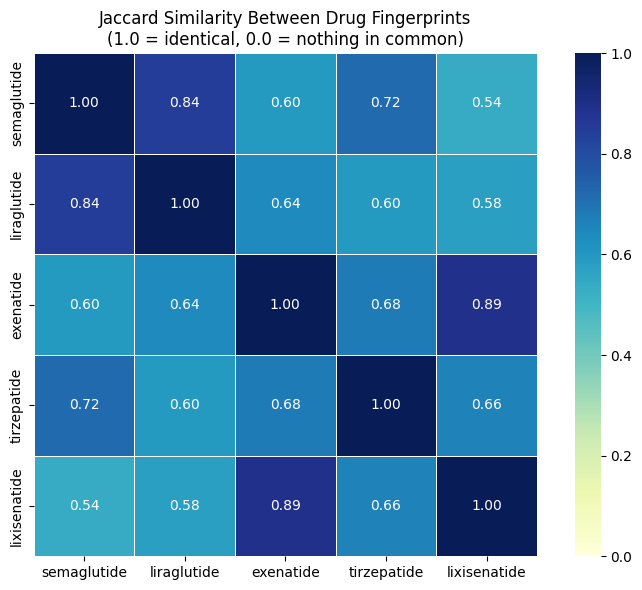


Jaccard similarity matrix:
              semaglutide  liraglutide  exenatide  tirzepatide  lixisenatide
semaglutide         1.000        0.844      0.596        0.719         0.536
liraglutide         0.844        1.000      0.643        0.597         0.576
exenatide           0.596        0.643      1.000        0.678         0.894
tirzepatide         0.719        0.597      0.678        1.000         0.663
lixisenatide        0.536        0.576      0.894        0.663         1.000


In [97]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Jaccard similarity matrix between all drugs ---
# Jaccard = bits in common / total bits set in either drug
fp_matrix = fp_df.drop(columns='drug_name').values  # shape (6, 2048)
drug_names = fp_df['drug_name'].tolist()
n = len(drug_names)

jaccard = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        intersection = (fp_matrix[i] & fp_matrix[j]).sum()
        union        = (fp_matrix[i] | fp_matrix[j]).sum()
        jaccard[i, j] = intersection / union if union > 0 else 0

jaccard_df = pd.DataFrame(jaccard, index=drug_names, columns=drug_names)

plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_df, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title('Jaccard Similarity Between Drug Fingerprints\n(1.0 = identical, 0.0 = nothing in common)')
plt.tight_layout()
plt.show()

print("\nJaccard similarity matrix:")
print(jaccard_df.round(3).to_string())

Bits shared by ALL 5 drugs: 101
Total bits in fingerprint: 2048

   drug_name  total_bits_set  unique_bits  shared_with_all
 semaglutide             156            0              101
 liraglutide             139            4              101
   exenatide             160            0              101
 tirzepatide             174            3              101
lixisenatide             162           10              101


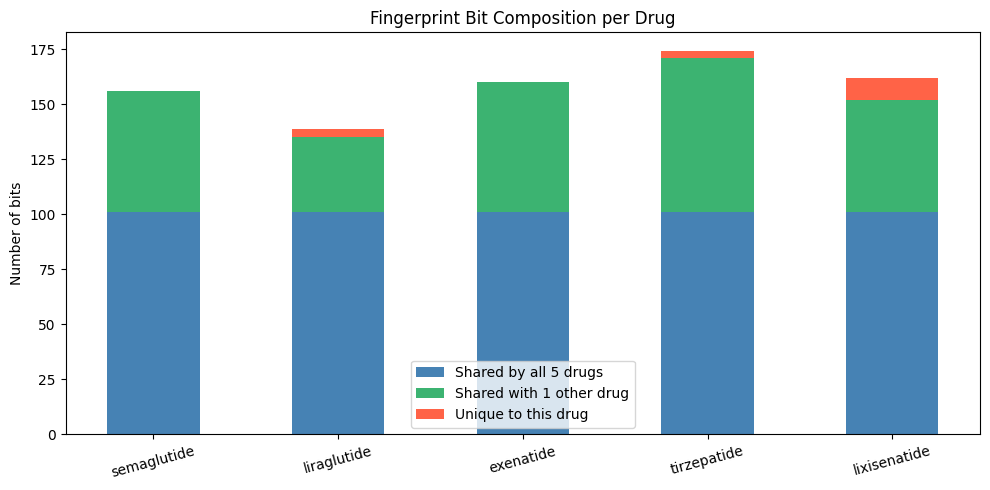

In [98]:
# --- Shared vs unique bit breakdown per drug ---
fp_bin = fp_matrix.astype(bool)

# A bit is "shared by all" if every drug has it set
shared_all  = fp_bin.all(axis=0).sum()
# A bit is "unique" to a drug if only that drug has it set
unique_counts = [(fp_bin[i] & ~fp_bin[np.arange(n) != i].any(axis=0)).sum()
                 for i in range(n)]
# Total bits set per drug
total_set = fp_bin.sum(axis=1)

summary = pd.DataFrame({
    'drug_name':    drug_names,
    'total_bits_set': total_set,
    'unique_bits':  unique_counts,
    'shared_with_all': shared_all
})
print(f"Bits shared by ALL {n} drugs: {shared_all}")
print(f"Total bits in fingerprint: 2048\n")
print(summary.to_string(index=False))

# Stacked bar: shared-all vs common (2+ drugs) vs unique
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(n)
w = 0.5

common_bits = [((fp_bin.sum(axis=0) >= 2) & fp_bin[i]).sum() - shared_all
               for i in range(n)]

ax.bar(x, [shared_all]*n,  width=w, label=f'Shared by all {n} drugs', color='steelblue')
ax.bar(x, common_bits,     width=w, bottom=[shared_all]*n, label='Shared with 1 other drug', color='mediumseagreen')
ax.bar(x, unique_counts,   width=w, bottom=[shared_all + c for c in common_bits], label='Unique to this drug', color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(drug_names, rotation=15)
ax.set_ylabel('Number of bits')
ax.set_title('Fingerprint Bit Composition per Drug')
ax.legend()
plt.tight_layout()
plt.show()

Bits that vary across drugs (differentiating): 114 / 2048



[22:12:21] DEPRECATION WARNING: please use MorganGenerator
[22:12:21] DEPRECATION WARNING: please use MorganGenerator
[22:12:21] DEPRECATION WARNING: please use MorganGenerator
[22:12:22] DEPRECATION WARNING: please use MorganGenerator
[22:12:22] DEPRECATION WARNING: please use MorganGenerator


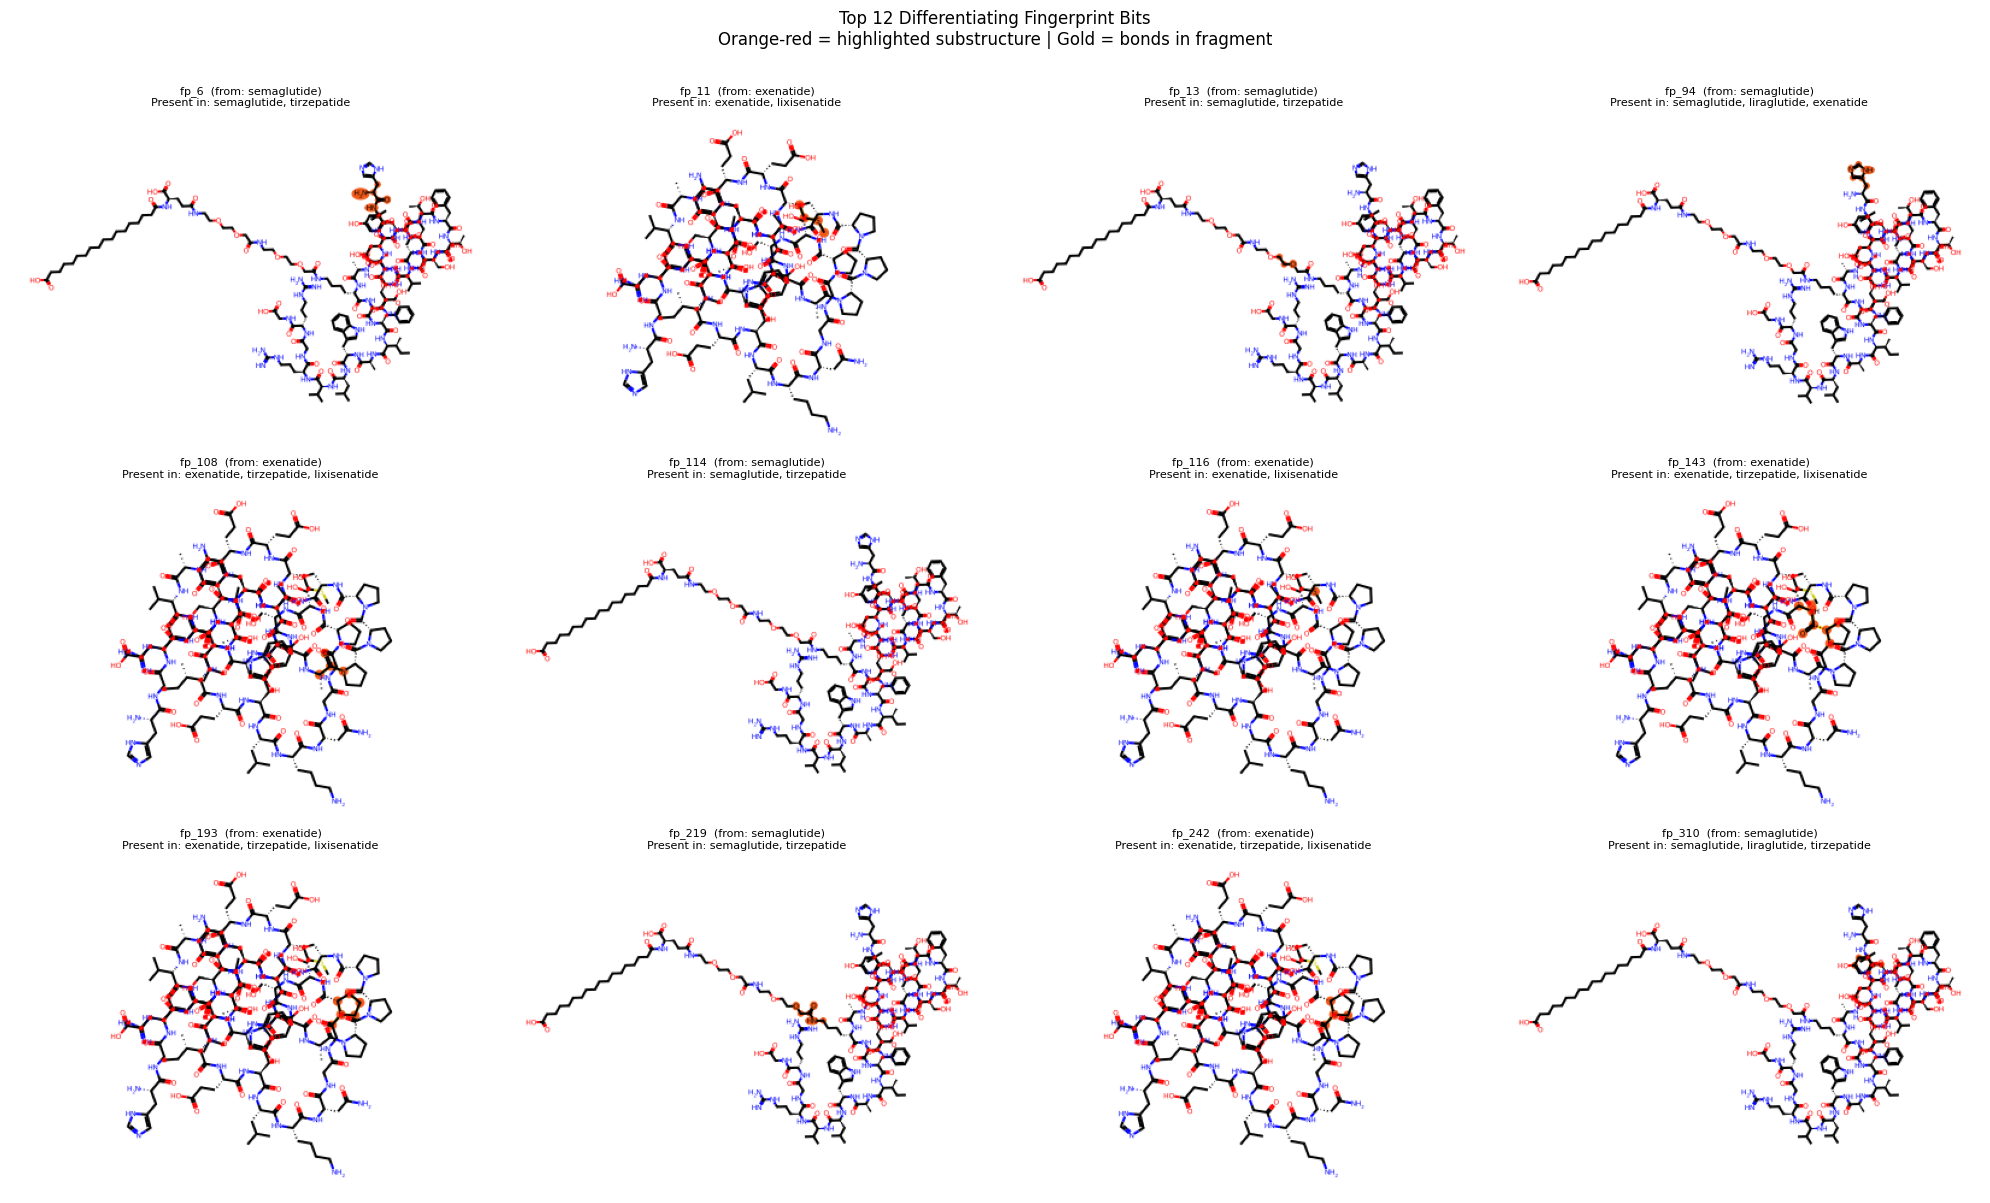

In [99]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdDepictor
from IPython.display import display, Image
import io
from PIL import Image as PILImage

# Find bits that vary across drugs
bit_cols = [f'fp_{i}' for i in range(2048)]
fp_df_bits = fp_df[bit_cols]
varying_bits = fp_df_bits.columns[fp_df_bits.std() > 0].tolist()
print(f"Bits that vary across drugs (differentiating): {len(varying_bits)} / 2048\n")

# Build bitInfo for each drug
bit_info_map = {}
for _, row in drug_df.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        rdDepictor.Compute2DCoords(mol)  # Generate 2D layout for cleaner drawing
        bi = {}
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bi)
        bit_info_map[row['drug_name']] = (mol, bi)

top_bits = [int(b.split('_')[1]) for b in varying_bits[:12]]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

# Bright highlight colors: atoms = orange-red, bonds = gold
ATOM_COLOR  = (0.95, 0.35, 0.1)   # vivid orange-red  (R, G, B  0-1)
BOND_COLOR  = (1.0,  0.75, 0.0)   # bright gold
BG_COLOR    = (1.0,  1.0,  1.0)   # white background

for idx, bit_idx in enumerate(top_bits):
    drew = False
    for drug, (mol, bi) in bit_info_map.items():
        if bit_idx in bi:
            atom_idx, radius = bi[bit_idx][0]

            # Collect all atoms + bonds in the circular environment
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
            hit_atoms = list(
                {mol.GetBondWithIdx(b).GetBeginAtomIdx() for b in env} |
                {mol.GetBondWithIdx(b).GetEndAtomIdx() for b in env} |
                {atom_idx}
            )
            hit_bonds = list(env)

            # Build per-atom and per-bond color dicts for explicit control
            atom_colors = {a: ATOM_COLOR for a in hit_atoms}
            bond_colors = {b: BOND_COLOR for b in hit_bonds}

            drawer = rdMolDraw2D.MolDraw2DCairo(400, 280)
            opts = drawer.drawOptions()
            opts.setBackgroundColour(BG_COLOR)
            opts.highlightRadius = 0.45        # thicker highlight ring
            opts.addAtomIndices = False

            drawer.DrawMolecule(
                mol,
                highlightAtoms=hit_atoms,
                highlightAtomColors=atom_colors,
                highlightBonds=hit_bonds,
                highlightBondColors=bond_colors,
            )
            drawer.FinishDrawing()

            bio = io.BytesIO(drawer.GetDrawingText())
            pil_img = PILImage.open(bio).convert("RGB")
            axes[idx].imshow(pil_img)
            axes[idx].axis('off')

            drugs_with = [d for d in drug_names
                          if fp_df.loc[fp_df['drug_name'] == d, f'fp_{bit_idx}'].values[0] == 1]
            axes[idx].set_title(
                f'fp_{bit_idx}  (from: {drug})\nPresent in: {", ".join(drugs_with)}',
                fontsize=8, pad=6
            )
            drew = True
            break
    if not drew:
        axes[idx].axis('off')

plt.suptitle(
    'Top 12 Differentiating Fingerprint Bits\n'
    'Orange-red = highlighted substructure | Gold = bonds in fragment',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


## Step 2c Unique Bits per Drug: Chemical Group Translation

In [101]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdDepictor
from rdkit.Chem import MolToSmiles, MolFragmentToSmiles
import pandas as pd

# Functional group SMARTS library 
# Ordered from more specific â†’ more general so the first match wins
FUNCTIONAL_GROUPS = [
    ('Disulfide',               '[SX2][SX2]'),
    ('Thioether (C-S-C)',        '[#6][SX2][#6]'),
    ('Thiol',                   '[SX2H]'),
    ('Indole (Trp side chain)',  'c1ccc2[nH]ccc2c1'),
    ('Imidazole (His side chain)','c1cn[nH]c1 |c1c[nH]cn1|c1cnc[nH]1'),
    ('Phenol (Tyr side chain)',  'c1ccc(O)cc1'),
    ('Phenyl ring',             'c1ccccc1'),
    ('Guanidine (Arg side chain)','[NX3][CX3](=[NX2])[NX3]'),
    ('Fatty acid / lipid chain', 'CCCCCCCC'),
    ('Carbamate (N-C(=O)-O)',    '[NX3][CX3](=[OX1])[OX2]'),
    ('Ester (C(=O)-O-C)',        '[#6][CX3](=[OX1])[OX2][#6]'),
    ('Amide bond (peptide)',     '[NX3][CX3](=[OX1])'),
    ('Carboxylic acid',         '[CX3](=[OX1])[OX2H1]'),
    ('Primary amine',           '[NX3;H2;!$(NC=O)]'),
    ('Secondary amine',         '[NX3;H1;!$(NC=O)]'),
    ('Hydroxyl group',          '[OX2H]'),
    ('Carbonyl (C=O)',          '[CX3]=[OX1]'),
    ('Isopropyl / Val/Leu branch','[CH3][CH]([CH3])'),
    ('Methyl branch',           '[CH3][CX4]'),
    ('Proline-like ring (N in ring)','[NX3;R][CX4;R]'),
    ('Cyclopentyl ring',        '[C;R1]1[C;R1][C;R1][C;R1][C;R1]1'),
    ('Cyclohexyl ring',         '[C;R1]1[C;R1][C;R1][C;R1][C;R1][C;R1]1'),
    ('Peptide backbone (N-Ca-C=O)','[NX3][CX4][CX3](=[OX1])'),
]

def match_groups(smiles_str):
    """Return list of matching functional group names for a fragment SMILES."""
    if not smiles_str or smiles_str == '(none)':
        return ['â€”']
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        return ['â€”']
    found = []
    for name, smarts in FUNCTIONAL_GROUPS:
        # Handle pipe-separated alternatives in smarts
        for s in smarts.split('|'):
            patt = Chem.MolFromSmarts(s.strip())
            if patt and mol.HasSubstructMatch(patt):
                found.append(name)
                break
    return found if found else ['Unique peptide environment']

# -- Rebuild bitInfo map with 2D coords 
for _, row in drug_df.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        rdDepictor.Compute2DCoords(mol)
        bi = {}
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bi)
        bit_info_map[row['drug_name']] = (mol, bi)

# Find bits unique to each drug (set in that drug, 0 in all others)
bit_cols = [f'fp_{i}' for i in range(2048)]
fp_mat = fp_df.set_index('drug_name')[bit_cols]

records = []
for drug in drug_names:
    this  = fp_mat.loc[drug]
    others = fp_mat.drop(index=drug)
    unique_bit_cols = this[(this == 1) & (others.max(axis=0) == 0)].index.tolist()

    mol, bi = bit_info_map.get(drug, (None, {}))
    if mol is None:
        continue

    # Collect all unique bits, prefer smaller radius (more interpretable)
    bit_details = []
    for bc in unique_bit_cols:
        bit_idx = int(bc.split('_')[1])
        if bit_idx in bi:
            # bi[bit_idx] is a list of (atom_idx, radius) tuples â€” take smallest radius
            atom_idx, radius = min(bi[bit_idx], key=lambda x: x[1])
            bit_details.append((bc, bit_idx, atom_idx, radius))

    # Sort by radius asc, then bit index
    bit_details.sort(key=lambda x: (x[3], x[1]))

    for bc, bit_idx, atom_idx, radius in bit_details:
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        frag_atoms = list(
            {mol.GetBondWithIdx(b).GetBeginAtomIdx() for b in env} |
            {mol.GetBondWithIdx(b).GetEndAtomIdx() for b in env} |
            {atom_idx}
        )
        frag_smiles = Chem.MolFragmentToSmiles(mol, frag_atoms, list(env)) or '(none)'
        groups = match_groups(frag_smiles)

        records.append({
            'Drug':            drug,
            'Bit':             bc,
            'Radius':          radius,
            'Fragment SMILES': frag_smiles,
            'Chemical Group':  ', '.join(groups),
        })

unique_df = pd.DataFrame(records)

print(f"Total unique bits across all 6 drugs: {len(unique_df)}\n")
print("Unique bits per drug:")
print(unique_df.groupby('Drug').size().rename('# unique bits').to_string())
print()

# Display: one table per drug, top 15 rows each 
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 200)

for drug in drug_names:
    sub = unique_df[unique_df['Drug'] == drug][['Bit','Radius','Fragment SMILES','Chemical Group']]
    if sub.empty:
        print(f"\n{drug}: no unique bits")
        continue
    print(f"\n{'='*70}")
    print(f"  {drug.upper()}  -  {len(sub)} unique bits  (showing first 15, sorted by radius)")
    print(f"{'='*70}")
    display(sub.head(15).reset_index(drop=True))


[22:13:57] DEPRECATION WARNING: please use MorganGenerator
[22:13:57] DEPRECATION WARNING: please use MorganGenerator
[22:13:57] DEPRECATION WARNING: please use MorganGenerator


Total unique bits across all 6 drugs: 17

Unique bits per drug:
Drug
liraglutide      4
lixisenatide    10
tirzepatide      3


semaglutide: no unique bits

  LIRAGLUTIDE  -  4 unique bits  (showing first 15, sorted by radius)


[22:13:57] DEPRECATION WARNING: please use MorganGenerator
[22:13:57] DEPRECATION WARNING: please use MorganGenerator
[22:13:57] non-ring atom 4 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 4 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic
[22:13:57] non-ring atom 0 marked aromatic


,Bit,Radius,Fragment SMILES,Chemical Group
0,fp_794,1,CCC,Methyl branch
1,fp_591,2,CCCC,Methyl branch
2,fp_890,2,C[C@H](N)C(=O)NC,"Amide bond (peptide), Primary amine, Carbonyl (C=O), Met..."
3,fp_1444,2,CCCCC,Methyl branch



exenatide: no unique bits

  TIRZEPATIDE  -  3 unique bits  (showing first 15, sorted by radius)


,Bit,Radius,Fragment SMILES,Chemical Group
0,fp_684,2,CNC(=O)[C@H](C)N,"Amide bond (peptide), Primary amine, Carbonyl (C=O), Met..."
1,fp_1017,2,C[C@@H](N)Cc(c)c,â€”
2,fp_1408,2,CNC(=O)[C@H](C)N,"Amide bond (peptide), Primary amine, Carbonyl (C=O), Met..."



  LIXISENATIDE  -  10 unique bits  (showing first 15, sorted by radius)


,Bit,Radius,Fragment SMILES,Chemical Group
0,fp_724,1,cc(C)n,â€”
1,fp_1145,1,c[nH]c,â€”
2,fp_1452,1,cnc,â€”
3,fp_575,2,cc(C)nc[nH],â€”
4,fp_625,2,cnc[nH]c,â€”
5,fp_785,2,C[C@@H](N)Cc(c)n,â€”
6,fp_931,2,cc[nH]cn,â€”
7,fp_1633,2,cnc(CC)c[nH],â€”
8,fp_1758,2,c[nH]cc(C)n,â€”
9,fp_2031,2,CN[C@@H](CC)C(N)=O,"Amide bond (peptide), Secondary amine, Carbonyl (C=O), M..."


# Step 3 ADMET Properties (ADMET-AI)

In [43]:
# only need to run first time
pip install admet_ai

     ---------------------------------------- 0.0/44.8 kB ? eta -:--:--
     ----------------- -------------------- 20.5/44.8 kB 682.7 kB/s eta 0:00:01
     -------------------------------------- 44.8/44.8 kB 735.4 kB/s eta 0:00:00
     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB ? eta 0:00:00
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/40.8 kB ? eta -:--:--
     ---------------------------------------- 40.8/40.8 kB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/82.2 kB ? eta -:--:--
     ---------------------------------------- 82.2/82.2 kB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.3 MB ? eta -:--:--
   - -------------------------------------- 0.6/14.3 MB 13.3 MB/s eta 0:00:02
   -- -------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\fquad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [102]:
from admet_ai import ADMETModel

admet_model = ADMETModel()

# Predict ADMET properties for all drugs with valid SMILES
valid_mask = drug_df['smiles'].notna()
valid_df = drug_df[valid_mask].reset_index(drop=True)

admet_preds = admet_model.predict(smiles=valid_df['smiles'].tolist())
admet_df = admet_preds.copy()
admet_df['drug_name'] = valid_df['drug_name'].values

print(f"ADMET shape: {admet_df.shape}")
admet_df.head()

model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


C:\Users\fquad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\fquad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\fquad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


model ensembles:  50%|█████     | 1/2 [00:00<00:00,  3.10it/s]GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


model ensembles: 100%|██████████| 2/2 [00:00<00:00,  3.43it/s]

ADMET shape: (5, 105)


,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,stereo_centers,tpsa,PAINS_alert,BRENK_alert,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,drug_name
CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CNC2=CC=CC=C21)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C(C)C)C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)O)NC(=O)[C@H](CC3=CC=CC=C3)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCNC(=O)COCCOCCNC(=O)COCCOCCNC(=O)CC[C@H](C(=O)O)NC(=O)CCCCCCCCCCCCCCCCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)N)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC4=CC=C(C=C4)O)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@H](C(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CC5=CC=CC=C5)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)C(C)(C)NC(=O)[C@H](CC6=CN=CN6)N,4113.641,-11.62786,56,57,1.0,0.009576,30,1646.18,0,3,...,0.386643,99.894552,4.393673,0.035149,97.398946,0.210896,4.393673,35.254833,0.246046,semaglutide
CCCCCCCCCCCCCCCC(=O)N[C@@H](CCC(=O)NCCCC[C@H](NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(N)=O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@@H](N)Cc1cnc[nH]1)[C@@H](C)O)[C@@H](C)O)C(C)C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(=O)N[C@H](C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)O)C(C)C)[C@@H](C)CC)C(=O)O,3751.262,-10.16166,49,54,1.0,0.009577,31,1513.76,0,3,...,0.281195,99.894552,10.123023,0.070299,98.945518,0.456942,12.583480,38.031634,0.105448,liraglutide
CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CCCNC(=N)N)NC(=O)[C@@H](NC(=O)[C@H](C)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCSC)NC(=O)[C@H](CCC(N)=O)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CO)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)CNC(=O)[C@@H](N)Cc1cnc[nH]1)[C@@H](C)O)[C@@H](C)O)C(C)C)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(N)=O)C(=O)NCC(=O)NCC(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)N[C@@H](CO)C(N)=O,4186.637,-20.60433,60,58,1.0,0.009763,37,1749.75,0,3,...,0.070299,99.894552,0.105448,0.035149,99.718805,0.175747,1.195079,64.674868,0.105448,exenatide
CC[C@H](C)[C@@H](C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CCCCNC(=O)COCCOCCNC(=O)COCCOCCNC(=O)CC[C@@H](C(=O)O)NC(=O)CCCCCCCCCCCCCCCCCCC(=O)O)C(=O)N[C@@H](C)C(=O)N[C@@H](CC1=CC=CC=C1)C(=O)N[C@@H](C(C)C)C(=O)N[C@@H](CCC(=O)N)C(=O)N[C@@H](CC2=CNC3=CC=CC=C32)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H]([C@@H](C)CC)C(=O)N[C@@H](C)C(=O)NCC(=O)NCC(=O)N4CCC[C@H]4C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)NCC(=O)N[C@@H](C)C(=O)N5CCC[C@H]5C(=O)N6CCC[C@H]6C(=O)N7CCC[C@H]7C(=O)N[C@@H](CO)C(=O)N)NC(=O)[C@H](CCCCN)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)C(C)(C)NC(=O)[C@H]([C@@H](C)CC)NC(=O)[C@H](CO)NC(=O)[C@H](CC8=CC=C(C=C8)O)NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@H](CC9=CC=CC=C9)NC(=O)[C@H]([C@@H](C)O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)C(C)(C)NC(=O)[C@H](CC1=CC=C(C=C1)O)N,4813.527,-12.09750,65,58,1.0,0.015769,39,1789.63,0,1,...,0.456942,99.929701,0.210896,0.035149,99.929701,4.885764,43.514938,51.564148,0.000000,tirzepatide
CC[C@H](C)[C@@H](C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@@H](

In [103]:
len(admet_df.columns)

105

In [104]:
# Merge fingerprints + ADMET into one drug_features dataframe
drug_features = fp_df.merge(admet_df, on='drug_name')

print(f"drug_features shape: {drug_features.shape}")
drug_features.head()

drug_features shape: (5, 2153)


,fp_0,fp_1,fp_2,fp_3,fp_4,fp_5,fp_6,fp_7,fp_8,fp_9,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,0,1,0,0,0,0,1,0,0,0,...,0.035149,0.386643,99.894552,4.393673,0.035149,97.398946,0.210896,4.393673,35.254833,0.246046
1,0,1,0,0,0,0,0,0,0,0,...,0.035149,0.281195,99.894552,10.123023,0.070299,98.945518,0.456942,12.583480,38.031634,0.105448
2,0,1,0,0,0,0,0,0,0,0,...,0.035149,0.070299,99.894552,0.105448,0.035149,99.718805,0.175747,1.195079,64.674868,0.105448
3,0,1,0,0,0,0,1,0,0,0,...,0.105448,0.456942,99.929701,0.210896,0.035149,99.929701,4.885764,43.514938,51.564148,0.000000
4,0,1,0,0,0,0,0,0,0,0,...,0.000000,0.035149,99.929701,0.351494,0.000000,99.859402,0.000000,0.105448,75.746924,0.175747


In [105]:
print(drug_features.shape)
print(drug_features.columns.tolist()[:5])
print(drug_features.columns.tolist()[-5:])

(5, 2153)
['fp_0', 'fp_1', 'fp_2', 'fp_3', 'fp_4']
['LD50_Zhu_drugbank_approved_percentile', 'Lipophilicity_AstraZeneca_drugbank_approved_percentile', 'PPBR_AZ_drugbank_approved_percentile', 'Solubility_AqSolDB_drugbank_approved_percentile', 'VDss_Lombardo_drugbank_approved_percentile']


# Step 4 - AACT Patient Data

In [ ]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

AACT_USER = # replace with username
AACT_PASS = # replace with password
AACT_HOST = "aact-db.ctti-clinicaltrials.org"
AACT_PORT = 5432
AACT_DB   = "aact"

pw = quote_plus(AACT_PASS)
engine = create_engine(f"postgresql+psycopg2://{AACT_USER}:{pw}@{AACT_HOST}:{AACT_PORT}/{AACT_DB}")

# Quick connection check
pd.read_sql("SELECT count(*) FROM studies;", engine)

,count
0,579010


In [109]:
from sqlalchemy import text

patient_query = """
WITH glp1_trials AS (
    SELECT DISTINCT ON (nct_id)
        nct_id,
        CASE
            -- Semaglutide: Ozempic (SC), Rybelsus (oral), Wegovy (obesity dose)
            WHEN LOWER(name) ILIKE '%semaglutide%'
              OR LOWER(name) ILIKE '%ozempic%'
              OR LOWER(name) ILIKE '%rybelsus%'
              OR LOWER(name) ILIKE '%wegovy%'   THEN 'semaglutide'
            -- Liraglutide: Victoza (T2D), Saxenda (obesity)
            WHEN LOWER(name) ILIKE '%liraglutide%'
              OR LOWER(name) ILIKE '%victoza%'
              OR LOWER(name) ILIKE '%saxenda%'  THEN 'liraglutide'
            -- Exenatide: Byetta (BID), Bydureon (weekly ER)
            WHEN LOWER(name) ILIKE '%exenatide%'
              OR LOWER(name) ILIKE '%byetta%'
              OR LOWER(name) ILIKE '%bydureon%' THEN 'exenatide'
            -- Tirzepatide: Mounjaro (T2D), Zepbound (obesity)
            WHEN LOWER(name) ILIKE '%tirzepatide%'
              OR LOWER(name) ILIKE '%mounjaro%'
              OR LOWER(name) ILIKE '%zepbound%' THEN 'tirzepatide'
            -- Lixisenatide: Lyxumia (EU), Adlyxin (US)
            WHEN LOWER(name) ILIKE '%lixisenatide%'
              OR LOWER(name) ILIKE '%lyxumia%'
              OR LOWER(name) ILIKE '%adlyxin%'  THEN 'lixisenatide'
            -- Albiglutide: Tanzeum (US), Eperzan (EU)
            WHEN LOWER(name) ILIKE '%albiglutide%'
              OR LOWER(name) ILIKE '%tanzeum%'
              OR LOWER(name) ILIKE '%eperzan%'  THEN 'albiglutide'
        END AS drug_name
    FROM interventions
    WHERE intervention_type = 'DRUG'
      AND (
            LOWER(name) ILIKE '%semaglutide%' OR LOWER(name) ILIKE '%ozempic%'
         OR LOWER(name) ILIKE '%rybelsus%'    OR LOWER(name) ILIKE '%wegovy%'
         OR LOWER(name) ILIKE '%liraglutide%' OR LOWER(name) ILIKE '%victoza%'
         OR LOWER(name) ILIKE '%saxenda%'
         OR LOWER(name) ILIKE '%exenatide%'   OR LOWER(name) ILIKE '%byetta%'
         OR LOWER(name) ILIKE '%bydureon%'
         OR LOWER(name) ILIKE '%tirzepatide%' OR LOWER(name) ILIKE '%mounjaro%'
         OR LOWER(name) ILIKE '%zepbound%'
         OR LOWER(name) ILIKE '%lixisenatide%' OR LOWER(name) ILIKE '%lyxumia%'
         OR LOWER(name) ILIKE '%adlyxin%'
         OR LOWER(name) ILIKE '%albiglutide%' OR LOWER(name) ILIKE '%tanzeum%'
         OR LOWER(name) ILIKE '%eperzan%'
      )
),

baseline AS (
    SELECT
        nct_id,
        AVG(CASE
            WHEN (LOWER(title) ILIKE '%hba1c%'
               OR LOWER(title) ILIKE '%hemoglobin a1c%'
               OR LOWER(title) ILIKE '%glycated hemoglobin%'
               OR LOWER(title) ILIKE '%glycohemoglobin%'
               OR LOWER(title) ILIKE '%glycosylated hemoglobin%'
               OR LOWER(title) ILIKE '% a1c%')
             AND param_value_num BETWEEN 4.0 AND 15.0
            THEN param_value_num
            WHEN (LOWER(title) ILIKE '%hba1c%'
               OR LOWER(title) ILIKE '%hemoglobin a1c%'
               OR LOWER(title) ILIKE '%glycated hemoglobin%'
               OR LOWER(title) ILIKE '%glycohemoglobin%'
               OR LOWER(title) ILIKE '%glycosylated hemoglobin%'
               OR LOWER(title) ILIKE '% a1c%')
             AND param_value_num BETWEEN 20.0 AND 150.0
            THEN 0.09148 * param_value_num + 2.152
        END) AS baseline_hba1c,
        AVG(CASE WHEN LOWER(title) ILIKE '%bmi%'
                   OR LOWER(title) ILIKE '%body mass index%'
                 THEN param_value_num END) AS bmi,
        AVG(CASE WHEN LOWER(title) ILIKE '%age%'
                 THEN param_value_num END) AS age,
        AVG(CASE WHEN LOWER(title) ILIKE '%duration of diabetes%'
                   OR LOWER(title) ILIKE '%diabetes duration%'
                   OR LOWER(title) ILIKE '%duration of type 2%'
                 THEN param_value_num END) AS diabetes_duration
    FROM baseline_measurements
    WHERE nct_id IN (SELECT nct_id FROM glp1_trials)
    GROUP BY nct_id
),

-- Absolute follow-up HbA1c values (% or mmol/mol)
outcome_absolute AS (
    SELECT om.nct_id,
        AVG(CASE
            WHEN om.param_value_num BETWEEN 4.0 AND 15.0
            THEN om.param_value_num
            WHEN om.param_value_num BETWEEN 20.0 AND 150.0
            THEN 0.09148 * om.param_value_num + 2.152
        END) AS follow_up_hba1c
    FROM outcome_measurements om
    JOIN outcomes o ON om.outcome_id = o.id
    WHERE om.nct_id IN (SELECT nct_id FROM glp1_trials)
      AND (
            LOWER(o.title) ILIKE '%hba1c%'
         OR LOWER(o.title) ILIKE '%hemoglobin a1c%'
         OR LOWER(o.title) ILIKE '%glycated hemoglobin%'
         OR LOWER(o.title) ILIKE '%glycohemoglobin%'
         OR LOWER(o.title) ILIKE '%glycosylated hemoglobin%'
         OR LOWER(o.title) ILIKE '% a1c %'
         OR LOWER(o.title) ILIKE '% a1c'
      )
      AND LOWER(o.title) NOT ILIKE '%change%'
      AND LOWER(o.title) NOT ILIKE '%difference%'
      AND LOWER(o.title) NOT ILIKE '%reduction%'
      AND (om.param_value_num BETWEEN 4.0 AND 15.0
           OR om.param_value_num BETWEEN 20.0 AND 150.0)
    GROUP BY om.nct_id
),

-- Direct delta / change-from-baseline scores
outcome_delta AS (
    SELECT om.nct_id,
        AVG(om.param_value_num) AS delta_hba1c_direct
    FROM outcome_measurements om
    JOIN outcomes o ON om.outcome_id = o.id
    WHERE om.nct_id IN (SELECT nct_id FROM glp1_trials)
      AND (
            LOWER(o.title) ILIKE '%change%hba1c%'
         OR LOWER(o.title) ILIKE '%hba1c%change%'
         OR LOWER(o.title) ILIKE '%change%hemoglobin a1c%'
         OR LOWER(o.title) ILIKE '%change%glycated%'
         OR LOWER(o.title) ILIKE '%change%glycosylated%'
         OR LOWER(o.title) ILIKE '%change from baseline%a1c%'
         OR LOWER(o.title) ILIKE '%change from baseline%hemoglobin%'
         OR LOWER(o.title) ILIKE '%reduction%hba1c%'
         OR LOWER(o.title) ILIKE '%hba1c%reduction%'
         OR LOWER(o.title) ILIKE '%reduction%hemoglobin a1c%'
         OR LOWER(o.title) ILIKE '%reduction% a1c%'
         OR LOWER(o.title) ILIKE '%difference%hba1c%'
         OR LOWER(o.title) ILIKE '%hba1c%week%'
         OR LOWER(o.title) ILIKE '%a1c%week%'
      )
      AND om.param_value_num BETWEEN -6.0 AND 1.5
    GROUP BY om.nct_id
)

SELECT
    t.nct_id,
    t.drug_name,
    b.baseline_hba1c,
    b.bmi,
    b.age,
    b.diabetes_duration,
    COALESCE(
        od.delta_hba1c_direct,
        oa.follow_up_hba1c - b.baseline_hba1c
    ) AS delta_hba1c
FROM glp1_trials t
LEFT JOIN baseline         b  ON t.nct_id = b.nct_id
LEFT JOIN outcome_absolute oa ON t.nct_id = oa.nct_id
LEFT JOIN outcome_delta    od ON t.nct_id = od.nct_id
WHERE
    (od.delta_hba1c_direct IS NOT NULL
     OR (oa.follow_up_hba1c IS NOT NULL AND b.baseline_hba1c IS NOT NULL))
    AND COALESCE(
            od.delta_hba1c_direct,
            oa.follow_up_hba1c - b.baseline_hba1c
        ) BETWEEN -6.0 AND 1.5
ORDER BY t.drug_name, t.nct_id;
"""

with engine.connect() as conn:
    patient_df = pd.read_sql(text(patient_query), conn)

print(f"patient_df shape: {patient_df.shape}  (was 227 rows before)")
print(f"\nDrugs found:")
print(patient_df['drug_name'].value_counts().to_string())
print(f"\nMissing values per column:")
print(patient_df.isnull().sum().to_string())
print(f"\ndelta_hba1c stats:")
print(patient_df['delta_hba1c'].describe().round(3))
patient_df.head()


patient_df shape: (231, 7)  (was 227 rows before)

Drugs found:
drug_name
liraglutide     69
semaglutide     61
exenatide       49
lixisenatide    24
tirzepatide     23
albiglutide      5

Missing values per column:
nct_id                 0
drug_name              0
baseline_hba1c       102
bmi                  179
age                    0
diabetes_duration    191
delta_hba1c            0

delta_hba1c stats:
count    231.000
mean      -0.904
std        0.586
min       -2.857
25%       -1.321
50%       -0.895
75%       -0.445
max        0.535
Name: delta_hba1c, dtype: float64


,nct_id,drug_name,baseline_hba1c,bmi,age,diabetes_duration,delta_hba1c
0,NCT00839527,albiglutide,NaN,NaN,55.275000,NaN,-0.372000
1,NCT01733758,albiglutide,NaN,NaN,58.280000,NaN,-0.762500
2,NCT01777282,albiglutide,NaN,NaN,57.550000,NaN,-1.148000
3,NCT02229227,albiglutide,NaN,NaN,58.066667,NaN,-0.884167
4,NCT02683746,albiglutide,NaN,NaN,57.100000,NaN,-1.075000


In [110]:
patient_df.groupby('drug_name')['delta_hba1c'].median()

drug_name
albiglutide    -0.884167
exenatide      -0.930000
liraglutide    -0.845000
lixisenatide   -0.686667
semaglutide    -1.025000
tirzepatide    -1.325000
Name: delta_hba1c, dtype: float64

In [111]:
len(patient_df)

231

## Step 4b - Enrich Patient Data (Labs, Demographics, Comorbidities, Trial Design)

In [112]:
from sqlalchemy import text
import pandas as pd

nct_ids = patient_df['nct_id'].tolist()
nct_placeholder = ', '.join([f"'{n}'" for n in nct_ids])

# 1. Additional baseline measurements -------------------------------------
baseline_extra_query = f"""
SELECT
    nct_id,
    -- Body composition
    AVG(CASE WHEN LOWER(title) ILIKE '%body weight%'
              OR LOWER(title) ILIKE '%weight (kg)%'
              OR (LOWER(title) ILIKE '%weight%' AND LOWER(units) ILIKE '%kg%')
             THEN param_value_num END)                              AS weight_kg,
    AVG(CASE WHEN LOWER(title) ILIKE '%waist%'
             THEN param_value_num END)                              AS waist_cm,

    -- Blood pressure
    AVG(CASE WHEN LOWER(title) ILIKE '%systolic%'
             THEN param_value_num END)                              AS systolic_bp,
    AVG(CASE WHEN LOWER(title) ILIKE '%diastolic%'
             THEN param_value_num END)                              AS diastolic_bp,

    -- Lipids
    AVG(CASE WHEN LOWER(title) ILIKE '%ldl%'
             THEN param_value_num END)                              AS ldl_cholesterol,
    AVG(CASE WHEN LOWER(title) ILIKE '%hdl%'
             THEN param_value_num END)                              AS hdl_cholesterol,
    AVG(CASE WHEN (LOWER(title) ILIKE '%total cholesterol%'
               OR LOWER(title) ILIKE '%cholesterol%')
              AND LOWER(title) NOT ILIKE '%ldl%'
              AND LOWER(title) NOT ILIKE '%hdl%'
             THEN param_value_num END)                              AS total_cholesterol,
    AVG(CASE WHEN LOWER(title) ILIKE '%triglyceride%'
             THEN param_value_num END)                              AS triglycerides,

    -- Renal
    AVG(CASE WHEN LOWER(title) ILIKE '%egfr%'
              OR LOWER(title) ILIKE '%glomerular filtration%'
             THEN param_value_num END)                              AS egfr,
    AVG(CASE WHEN LOWER(title) ILIKE '%creatinine%'
             THEN param_value_num END)                              AS creatinine,

    -- Glucose
    AVG(CASE WHEN LOWER(title) ILIKE '%fasting plasma glucose%'
              OR LOWER(title) ILIKE '%fasting blood glucose%'
              OR LOWER(title) ILIKE '%fasting glucose%'
             THEN param_value_num END)                              AS fasting_glucose,

    -- Demographics
    AVG(CASE WHEN LOWER(title) ILIKE '%female%'
              AND param_type = 'COUNT'
             THEN param_value_num END)                              AS n_female,
    AVG(CASE WHEN LOWER(title) ILIKE '%male%'
              AND LOWER(title) NOT ILIKE '%female%'
              AND param_type = 'COUNT'
             THEN param_value_num END)                              AS n_male,

    -- Diabetes history
    AVG(CASE WHEN LOWER(title) ILIKE '%insulin%'
              AND LOWER(title) NOT ILIKE '%c-peptide%'
             THEN param_value_num END)                              AS pct_on_insulin,
    AVG(CASE WHEN LOWER(title) ILIKE '%metformin%'
             THEN param_value_num END)                              AS pct_on_metformin

FROM baseline_measurements
WHERE nct_id IN ({nct_placeholder})
  AND param_type IN ('MEAN', 'MEDIAN', 'LEAST SQUARES MEAN', 'COUNT', 'NUMBER')
  AND param_value_num IS NOT NULL
GROUP BY nct_id
"""

with engine.connect() as conn:
    baseline_extra = pd.read_sql(text(baseline_extra_query), conn)

# Force numeric dtype on all columns except nct_id
for col in baseline_extra.columns:
    if col != 'nct_id':
        baseline_extra[col] = pd.to_numeric(baseline_extra[col], errors='coerce')

# Compute % female where both counts are available
mask = baseline_extra['n_female'].notna() & baseline_extra['n_male'].notna()
total = baseline_extra.loc[mask, 'n_female'] + baseline_extra.loc[mask, 'n_male']
baseline_extra.loc[mask, 'pct_female'] = (baseline_extra.loc[mask, 'n_female'] / total * 100).round(1)
baseline_extra.drop(columns=['n_female', 'n_male'], inplace=True)

print(f"Extra baseline shape: {baseline_extra.shape}")
baseline_extra


Extra baseline shape: (227, 15)


,nct_id,weight_kg,waist_cm,systolic_bp,diastolic_bp,ldl_cholesterol,hdl_cholesterol,total_cholesterol,triglycerides,egfr,creatinine,fasting_glucose,pct_on_insulin,pct_on_metformin,pct_female
0,NCT00082381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NCT00082407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NCT00097500,91.463333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NCT00135330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NCT00294723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,NCT05564117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
223,NCT05616013,107.498000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
224,NCT05691712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225,NCT05706506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
# -- 2. Comorbidity flags from conditions table -----------
conditions_query = f"""
SELECT nct_id, LOWER(name) AS condition
FROM conditions
WHERE nct_id IN ({nct_placeholder})
"""

with engine.connect() as conn:
    conditions_raw = pd.read_sql(text(conditions_query), conn)

# Binary flag for each comorbidity category
COMORBIDITIES = {
    'has_obesity':        ['obes', 'overweight'],
    'has_hypertension':   ['hypertension', 'high blood pressure'],
    'has_cvd':            ['cardiovascular', 'coronary', 'heart disease',
                           'myocardial', 'atherosclerosis', 'stroke', 'cerebrovascular'],
    'has_ckd':            ['kidney', 'renal', 'ckd', 'nephropathy', 'creatinine'],
    'has_dyslipidemia':   ['dyslipidemia', 'hyperlipidemia', 'hypercholesterol'],
    'has_nafld':          ['nafld', 'nash', 'fatty liver'],
    'has_neuropathy':     ['neuropathy'],
    'has_retinopathy':    ['retinopathy'],
}

comorbidity_flags = conditions_raw.groupby('nct_id').apply(
    lambda grp: pd.Series({
        flag: int(any(kw in cond for cond in grp['condition'] for kw in keywords))
        for flag, keywords in COMORBIDITIES.items()
    })
).reset_index()

print(f"Comorbidity flags shape: {comorbidity_flags.shape}")
print("\nTrials with each comorbidity:")
print(comorbidity_flags[list(COMORBIDITIES.keys())].sum().to_string())
comorbidity_flags.head()


Comorbidity flags shape: (231, 9)

Trials with each comorbidity:
has_obesity         39
has_hypertension     0
has_cvd              0
has_ckd              2
has_dyslipidemia     0
has_nafld            1
has_neuropathy       0
has_retinopathy      0


C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\2455811484.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comorbidity_flags = conditions_raw.groupby('nct_id').apply(


,nct_id,has_obesity,has_hypertension,has_cvd,has_ckd,has_dyslipidemia,has_nafld,has_neuropathy,has_retinopathy
0,NCT00082381,0,0,0,0,0,0,0,0
1,NCT00082407,0,0,0,0,0,0,0,0
2,NCT00097500,0,0,0,0,0,0,0,0
3,NCT00135330,0,0,0,0,0,0,0,0
4,NCT00294723,0,0,0,0,0,0,0,0


In [114]:
# 3. Trial design features from studies + designs + eligibilities --
design_query = f"""
SELECT
    s.nct_id,
    s.phase,
    s.enrollment                                                    AS trial_enrollment,
    s.number_of_arms,
    (s.completion_date - s.start_date) / 7.0                       AS trial_duration_weeks,
    d.allocation,
    d.intervention_model,
    NULLIF(regexp_replace(e.minimum_age, '[^0-9]', '', 'g'), '')::numeric  AS min_age_eligible,
    NULLIF(regexp_replace(e.maximum_age, '[^0-9]', '', 'g'), '')::numeric  AS max_age_eligible
FROM studies s
LEFT JOIN designs       d ON s.nct_id = d.nct_id
LEFT JOIN eligibilities e ON s.nct_id = e.nct_id
WHERE s.nct_id IN ({nct_placeholder})
"""

with engine.connect() as conn:
    design_df = pd.read_sql(text(design_query), conn)

# Force numeric
for col in ['trial_enrollment', 'trial_duration_weeks', 'number_of_arms',
            'min_age_eligible', 'max_age_eligible']:
    design_df[col] = pd.to_numeric(design_df[col], errors='coerce')

# Encode categoricals
design_df['is_randomized'] = (design_df['allocation'] == 'RANDOMIZED').astype(int)
design_df['is_parallel']   = (design_df['intervention_model'] == 'PARALLEL').astype(int)
design_df['is_phase3']     = design_df['phase'].str.contains('3', na=False).astype(int)
design_df.drop(columns=['allocation', 'intervention_model', 'phase'], inplace=True, errors='ignore')

print(f"Design features shape: {design_df.shape}")
design_df.head()


Design features shape: (231, 9)


,nct_id,trial_enrollment,number_of_arms,trial_duration_weeks,min_age_eligible,max_age_eligible,is_randomized,is_parallel,is_phase3
0,NCT00082381,551,2.0,265.428571,30.0,75.0,1,1,1
1,NCT00082407,505,2.0,243.571429,30.0,75.0,1,1,1
2,NCT00097500,69,2.0,274.000000,30.0,75.0,1,1,1
3,NCT00135330,137,3.0,143.428571,18.0,75.0,1,1,1
4,NCT00294723,746,4.0,143.714286,18.0,80.0,1,1,1


In [115]:
enriched_patient_df = (
    patient_df
    .merge(baseline_extra,    on='nct_id', how='left')
    .merge(comorbidity_flags, on='nct_id', how='left')
    .merge(design_df,         on='nct_id', how='left')
)

# Drop columns that were entirely missing (no trials reported them)
before = enriched_patient_df.shape[1]
enriched_patient_df.drop(
    columns=enriched_patient_df.columns[enriched_patient_df.isnull().all()],
    inplace=True
)
after = enriched_patient_df.shape[1]
print(f"enriched_patient_df shape: {enriched_patient_df.shape}")
print(f"Dropped {before - after} all-null columns")

print(f"\nMissing values per column:")
print(enriched_patient_df.isnull().sum().to_string())
enriched_patient_df.head()


enriched_patient_df shape: (231, 35)
Dropped 2 all-null columns

Missing values per column:
nct_id                    0
drug_name                 0
baseline_hba1c          102
bmi                     179
age                       0
diabetes_duration       191
delta_hba1c               0
weight_kg               150
waist_cm                226
systolic_bp             223
diastolic_bp            223
ldl_cholesterol         227
hdl_cholesterol         227
total_cholesterol       229
triglycerides           227
creatinine              230
fasting_glucose         181
pct_on_insulin          218
pct_on_metformin        218
has_obesity               0
has_hypertension          0
has_cvd                   0
has_ckd                   0
has_dyslipidemia          0
has_nafld                 0
has_neuropathy            0
has_retinopathy           0
trial_enrollment          0
number_of_arms            3
trial_duration_weeks      0
min_age_eligible          1
max_age_eligible        153
is_randomize

,nct_id,drug_name,baseline_hba1c,bmi,age,diabetes_duration,delta_hba1c,weight_kg,waist_cm,systolic_bp,...,has_neuropathy,has_retinopathy,trial_enrollment,number_of_arms,trial_duration_weeks,min_age_eligible,max_age_eligible,is_randomized,is_parallel,is_phase3
0,NCT00839527,albiglutide,NaN,NaN,55.275000,NaN,-0.372000,NaN,NaN,NaN,...,0,0,685,3.0,217.428571,18.0,NaN,1,1,1
1,NCT01733758,albiglutide,NaN,NaN,58.280000,NaN,-0.762500,NaN,NaN,NaN,...,0,0,494,4.0,104.285714,20.0,NaN,1,1,1
2,NCT01777282,albiglutide,NaN,NaN,57.550000,NaN,-1.148000,NaN,NaN,NaN,...,0,0,374,5.0,100.428571,20.0,NaN,1,1,1
3,NCT02229227,albiglutide,NaN,NaN,58.066667,NaN,-0.884167,NaN,NaN,NaN,...,0,0,814,2.0,139.428571,18.0,NaN,1,1,1
4,NCT02683746,albiglutide,NaN,NaN,57.100000,NaN,-1.075000,NaN,NaN,NaN,...,0,0,308,2.0,60.714286,18.0,80.0,1,1,1


In [116]:
# Drop columns that are >90% missing â€” too sparse to be useful as features
threshold = 0.90
n = len(enriched_patient_df)
sparse_cols = [c for c in enriched_patient_df.columns
               if enriched_patient_df[c].isnull().sum() / n > threshold]

# Never drop the target or identifiers
sparse_cols = [c for c in sparse_cols if c not in ('nct_id', 'drug_name', 'delta_hba1c')]

enriched_patient_df.drop(columns=sparse_cols, inplace=True)

print(f"Dropped {len(sparse_cols)} sparse columns (>90% missing):")
for c in sparse_cols:
    print(f"  {c}")

print(f"\nFinal enriched_patient_df shape: {enriched_patient_df.shape}")
print(f"\nRemaining columns and their missing %:")
miss = (enriched_patient_df.isnull().sum() / n * 100).round(1)
print(miss[miss > 0].to_string())
print("\nFully populated columns:", miss[miss == 0].index.tolist())


Dropped 10 sparse columns (>90% missing):
  waist_cm
  systolic_bp
  diastolic_bp
  ldl_cholesterol
  hdl_cholesterol
  total_cholesterol
  triglycerides
  creatinine
  pct_on_insulin
  pct_on_metformin

Final enriched_patient_df shape: (231, 25)

Remaining columns and their missing %:
baseline_hba1c       44.2
bmi                  77.5
diabetes_duration    82.7
weight_kg            64.9
fasting_glucose      78.4
number_of_arms        1.3
min_age_eligible      0.4
max_age_eligible     66.2

Fully populated columns: ['nct_id', 'drug_name', 'age', 'delta_hba1c', 'has_obesity', 'has_hypertension', 'has_cvd', 'has_ckd', 'has_dyslipidemia', 'has_nafld', 'has_neuropathy', 'has_retinopathy', 'trial_enrollment', 'trial_duration_weeks', 'is_randomized', 'is_parallel', 'is_phase3']


In [117]:
# Drop trial design columns that describe data collection, not patient biology.
# These are not available at inference time for a real patient prediction.
trial_design_cols = [
    'is_randomized',      # methodological artifact
    'is_parallel',        # methodological artifact
    'is_phase3',          # correlated with drug identity, not patient response
    'number_of_arms',     # data quality metric, not clinical signal
    'trial_enrollment',   # trial size â‰  patient response
    'min_age_eligible',   # eligibility criterion, not patient characteristic
    'max_age_eligible',   # eligibility criterion, not patient characteristic
]
# Only drop columns that actually exist (in case of re-runs)
to_drop = [c for c in trial_design_cols if c in enriched_patient_df.columns]
enriched_patient_df.drop(columns=to_drop, inplace=True)

print(f"Dropped {len(to_drop)} trial design columns: {to_drop}")
print(f"enriched_patient_df shape: {enriched_patient_df.shape}")
print(f"\nFinal columns going into Step 5:")
for c in enriched_patient_df.columns:
    print(f"  {c}")


Dropped 7 trial design columns: ['is_randomized', 'is_parallel', 'is_phase3', 'number_of_arms', 'trial_enrollment', 'min_age_eligible', 'max_age_eligible']
enriched_patient_df shape: (231, 18)

Final columns going into Step 5:
  nct_id
  drug_name
  baseline_hba1c
  bmi
  age
  diabetes_duration
  delta_hba1c
  weight_kg
  fasting_glucose
  has_obesity
  has_hypertension
  has_cvd
  has_ckd
  has_dyslipidemia
  has_nafld
  has_neuropathy
  has_retinopathy
  trial_duration_weeks


# Step 5 - Merge drug features with patient data

In [118]:
# Merge enriched patient data with drug molecular features (fingerprints + ADMET)
# Inner join ensures only drugs with valid SMILES/fingerprints are included
final_df = enriched_patient_df.merge(drug_features, on='drug_name', how='inner')

print(f"final_df shape: {final_df.shape}")
print(f"\nDrugs in final_df: {final_df['drug_name'].value_counts().to_dict()}")
print(f"\nNull counts in patient feature columns:")
patient_feature_cols = ['baseline_hba1c', 'bmi', 'age', 'diabetes_duration',
                        'weight_kg', 'fasting_glucose', 'trial_duration_weeks']
print(final_df[patient_feature_cols].isnull().sum().to_string())
final_df.head(3)


final_df shape: (226, 2170)

Drugs in final_df: {'liraglutide': 69, 'semaglutide': 61, 'exenatide': 49, 'lixisenatide': 24, 'tirzepatide': 23}

Null counts in patient feature columns:
baseline_hba1c           97
bmi                     174
age                       0
diabetes_duration       186
weight_kg               145
fasting_glucose         176
trial_duration_weeks      0


,nct_id,drug_name,baseline_hba1c,bmi,age,diabetes_duration,delta_hba1c,weight_kg,fasting_glucose,has_obesity,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,NCT00082381,exenatide,NaN,NaN,58.890000,NaN,-1.025,NaN,NaN,0,...,0.035149,0.070299,99.894552,0.105448,0.035149,99.718805,0.175747,1.195079,64.674868,0.105448
1,NCT00082407,exenatide,NaN,NaN,98.166667,NaN,-0.930,NaN,NaN,0,...,0.035149,0.070299,99.894552,0.105448,0.035149,99.718805,0.175747,1.195079,64.674868,0.105448
2,NCT00097500,exenatide,7.496667,30.506667,58.366667,4.856667,-0.920,91.463333,NaN,0,...,0.035149,0.070299,99.894552,0.105448,0.035149,99.718805,0.175747,1.195079,64.674868,0.105448


In [ ]:
# Build feature matrix and targets
# Exclude identifiers and the target â€” everything else is a feature
feature_cols = [c for c in final_df.columns
                if c not in ('nct_id', 'drug_name', 'delta_hba1c')]

X = final_df[feature_cols].astype(float)  # NaNs left as-is - XGBoost handles natively
y_reg = final_df['delta_hba1c'].astype(float)
y_clf = (final_df['delta_hba1c'] < -1.0).astype(int)  # 1 = clinically meaningful responder
groups = final_df['nct_id']

print(f"X shape: {X.shape}")
print(f"\nFeature breakdown:")
print(f"  Fingerprint bits (fp_0..fp_2047):  {sum(c.startswith('fp_') for c in feature_cols)}")
print(f"  ADMET properties:                  {sum(not c.startswith('fp_') and c not in ['baseline_hba1c','bmi','age','diabetes_duration','weight_kg','fasting_glucose','trial_duration_weeks'] and not c.startswith('has_') for c in feature_cols)}")
print(f"  Patient labs/demographics:         {sum(c in ['baseline_hba1c','bmi','age','diabetes_duration','weight_kg','fasting_glucose'] for c in feature_cols)}")
print(f"  Comorbidity flags:                 {sum(c.startswith('has_') for c in feature_cols)}")
print(f"  Treatment duration:                {sum(c == 'trial_duration_weeks' for c in feature_cols)}")
print(f"\ny_reg range: {y_reg.min():.2f} to {y_reg.max():.2f}")
print(f"y_clf balance - responders (1): {y_clf.sum()}  non-responders (0): {(y_clf==0).sum()}")
print(f"\nNaN values in X: {X.isnull().sum().sum()} total across all cells")


X shape: (226, 2167)

Feature breakdown:
  Fingerprint bits (fp_0..fp_2047):  2048
  ADMET properties:                  104
  Patient labs/demographics:         6
  Comorbidity flags:                 8
  Treatment duration:                1

y_reg range: -2.86 to 0.54
y_clf balance - responders (1): 100  non-responders (0): 126

NaN values in X: 778 total across all cells


# Step 6 - Train XGBoost Models

In [84]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.7 MB 1.1 MB/s eta 0:01:30
   ---------------------------------------- 0.5/101.7 MB 3.8 MB/s eta 0:00:27
    --------------------------------------- 1.8/101.7 MB 10.6 MB/s eta 0:00:10
   - -------------------------------------- 4.6/101.7 MB 20.9 MB/s eta 0:00:05
   -- ------------------------------------- 6.9/101.7 MB 25.8 MB/s eta 0:00:04
   --- ------------------------------------ 9.3/101.7 MB 33.2 MB/s eta 0:00:03
   ---- ----------------------------------- 11.8/101.7 MB 54.4 MB/s eta 0:00:02
   ------ --------------------------------- 16.0/101.7 MB 72.6 MB/s eta 0:00:02
   ------- -------------------------------- 18.0/101.7 MB 72.6 MB/s eta 0:00:02
   -------- ------------------------------- 22.4/101.7 MB 81.8 MB/s eta 0:00:01
   ---------- ----------------------------- 26.0/101.7 MB 73.1 MB/


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\fquad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [120]:
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
import numpy as np
import pickle

# Train/test split â€” keep same trial in one split only
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_reg, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_reg_train, y_reg_test = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
y_clf_train, y_clf_test = y_clf.iloc[train_idx], y_clf.iloc[test_idx]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Test drugs: {final_df['drug_name'].iloc[test_idx].value_counts().to_dict()}")

Train: 180 rows | Test: 46 rows
Test drugs: {'liraglutide': 15, 'semaglutide': 12, 'exenatide': 9, 'tirzepatide': 7, 'lixisenatide': 3}


In [121]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
import numpy as np

# Shared hyperparameters tuned for high-dimensional (2167 features) + small sample (231 rows)
SHARED_PARAMS = dict(
    n_estimators      = 200,
    max_depth         = 3,       # shallow trees - reduces overfitting
    learning_rate     = 0.05,    # slower learning - better generalization
    subsample         = 0.8,     # row sampling per tree
    colsample_bytree  = 0.1,     # sample only ~217 features per tree (prevents fingerprint dominance)
    min_child_weight  = 5,       # leaf must have -5 samples - key guard against overfitting
    reg_alpha         = 0.1,     # L1 regularization - drives sparse feature weights to zero
    reg_lambda        = 1.0,     # L2 regularization (XGBoost default)
    random_state      = 42,
    verbosity         = 0,
)

# --- Regression model ---
reg_model = xgb.XGBRegressor(**SHARED_PARAMS)
reg_model.fit(X_train, y_reg_train)

y_pred_reg = reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)
print(f"Regression  - RMSE: {rmse:.3f}  |  RÂ²: {r2:.3f}")

# --- Classification model ---
clf_model = xgb.XGBClassifier(**SHARED_PARAMS, eval_metric='logloss')
clf_model.fit(X_train, y_clf_train)

if len(y_clf_test.unique()) > 1:
    auc = roc_auc_score(y_clf_test, clf_model.predict_proba(X_test)[:, 1])
    print(f"Classification - AUC-ROC: {auc:.3f}")
else:
    print("Classification - only one class in test set, AUC not computed")

print(f"\nTrain size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Note: metrics on {len(X_test)}-row test set - treat as directional for a POC at this data scale")


Regression  - RMSE: 0.488  |  RÂ²: 0.453
Classification - AUC-ROC: 0.830

Train size: 180  |  Test size: 46
Note: metrics on 46-row test set - treat as directional for a POC at this data scale


In [122]:
import pickle, os

save_dir = '../'
os.makedirs(save_dir, exist_ok=True)

with open(f'{save_dir}reg_model.pkl', 'wb') as f:
    pickle.dump(reg_model, f)

with open(f'{save_dir}clf_model.pkl', 'wb') as f:
    pickle.dump(clf_model, f)

with open(f'{save_dir}feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

# drug_features: molecular fingerprints + ADMET per drug
# The web app uses this to look up drug columns when a drug is selected
with open(f'{save_dir}drug_features.pkl', 'wb') as f:
    pickle.dump(drug_features, f)

print("Saved to", os.path.abspath(save_dir))
print("  reg_model.pkl      - XGBoost regressor (predicts HbA1c)")
print("  clf_model.pkl      - XGBoost classifier (P(HbA1c < -1%))")
print("  feature_cols.pkl   - ordered list of 2,167 feature column names")
print("  drug_features.pkl  - fingerprints + ADMET per drug (lookup table for UI)")


Saved to c:\capstone_project
  reg_model.pkl      - XGBoost regressor (predicts HbA1c)
  clf_model.pkl      - XGBoost classifier (P(HbA1c < -1%))
  feature_cols.pkl   - ordered list of 2,167 feature column names
  drug_features.pkl  - fingerprints + ADMET per drug (lookup table for UI)


# Step 7 - SHAP Analysis

In [97]:
pip install shap

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   -------------- ------------------------- 194.6/554.9 kB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 554.9/554.9 kB 6.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.4/38.1 MB 12.9 MB/s eta 0:00:03
    --------------------------------------- 0.9/38.1 MB 11.7 MB/s eta 0:00:04
   - -------------------------------------- 1.3/38.1 MB 9.2 MB/s eta 0:00:05
   - -------------------------------------- 1.9/38.1 MB 10.9 MB/s eta 0:00:04
   -- ------------------------------------- 2.5/38.1 MB 11.3 MB/s eta 0:00:04
   --- ------------------------------------ 3.6/38.1 MB 13.5 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/38.1 MB 13.6 MB/s eta 0:00:03
   ----- ---------------------------------- 5.6/38.1 MB 14.9 MB/s eta 0:00:03
   ------ --------------------------------- 6.5/38.1 MB 15.4 MB/s eta 0:00:0


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\fquad\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\295620101.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, plot_type='bar', max_display=20, show=False)


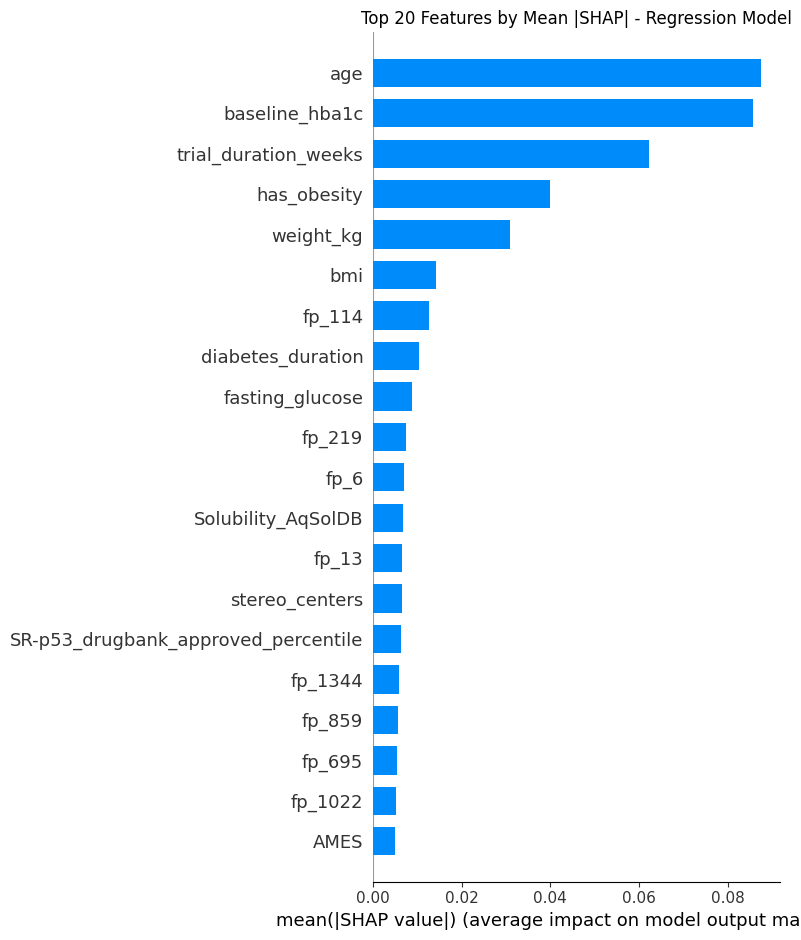

In [123]:
import shap
import matplotlib.pyplot as plt

# Compute SHAP values on the full dataset using the regression model
explainer = shap.TreeExplainer(reg_model)
shap_values = explainer.shap_values(X)

# Summary bar plot â€” top 20 features by mean |SHAP|
shap.summary_plot(shap_values, X, plot_type='bar', max_display=20, show=False)
plt.title('Top 20 Features by Mean |SHAP| - Regression Model')
plt.tight_layout()
plt.show()

C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\2199858582.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, max_display=20, show=False)


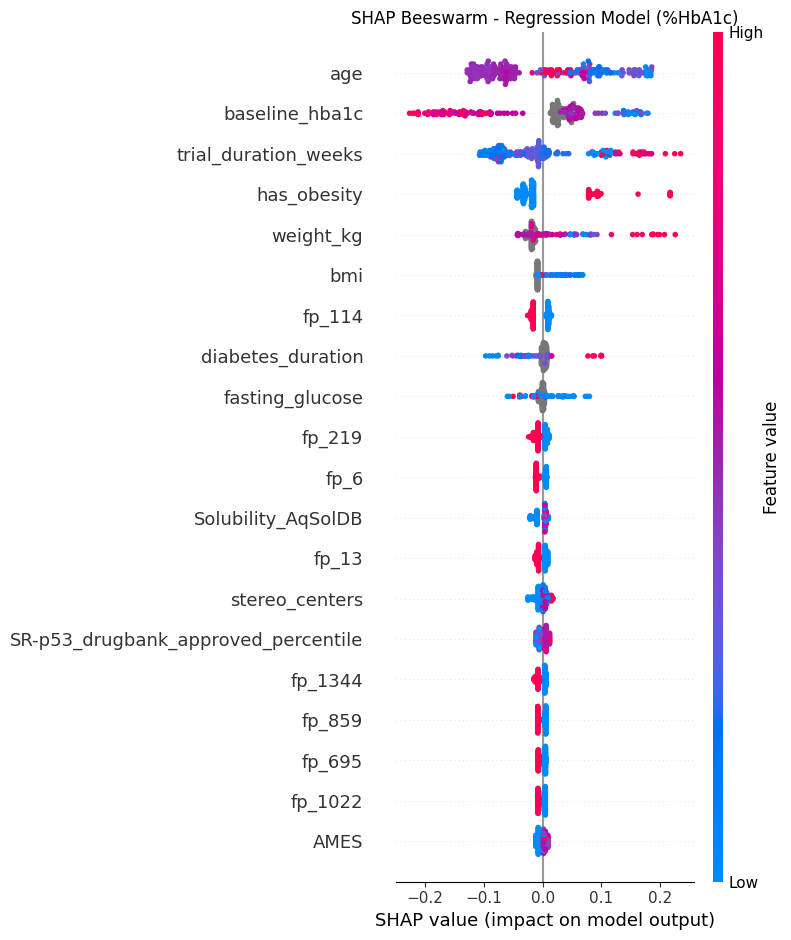

In [124]:
# Beeswarm plot â€” shows direction and magnitude of feature effects
shap.summary_plot(shap_values, X, max_display=20, show=False)
plt.title('SHAP Beeswarm - Regression Model (%HbA1c)')
plt.tight_layout()
plt.show()

In [127]:
import pandas as pd

shap_importance = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap': abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 20 most important features:")
print(shap_importance.head(20).to_string(index=False))

# Feature category breakdown
def categorize(f):
    if f.startswith('fp_'):      return 'Fingerprint bit'
    if f.startswith('has_'):     return 'Comorbidity flag'
    if f == 'trial_duration_weeks': return 'Treatment context'
    if f in ('baseline_hba1c', 'bmi', 'age', 'diabetes_duration',
             'weight_kg', 'fasting_glucose'): return 'Patient lab/demographic'
    return 'ADMET property'

shap_importance['category'] = shap_importance['feature'].apply(categorize)

print("\nMean |SHAP| by feature category")
cat_summary = (shap_importance.groupby('category')
               .agg(n_features=('feature', 'count'),
                    total_shap=('mean_abs_shap', 'sum'),
                    top_feature=('feature', 'first'))
               .sort_values('total_shap', ascending=False))
print(cat_summary.to_string())

print("\n-- Top 5 within each category")
for cat, grp in shap_importance.groupby('category'):
    print(f"\n{cat}:")
    print(grp.head(5)[['feature', 'mean_abs_shap']].to_string(index=False))


Top 20 most important features:
                            feature  mean_abs_shap
                                age       0.087463
                     baseline_hba1c       0.085717
               trial_duration_weeks       0.062161
                        has_obesity       0.039954
                          weight_kg       0.030910
                                bmi       0.014216
                             fp_114       0.012513
                  diabetes_duration       0.010288
                    fasting_glucose       0.008835
                             fp_219       0.007492
                               fp_6       0.006921
                 Solubility_AqSolDB       0.006798
                              fp_13       0.006615
                     stereo_centers       0.006556
SR-p53_drugbank_approved_percentile       0.006339
                            fp_1344       0.005758
                             fp_859       0.005691
                             fp_695       0.005295

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
# mol = Chem.MolFromSmiles('your_molecule_smiles')
info = {}
fp = AllChem.GetMorganFingerprintAsBitVect('fp_114', radius=2, nBits=2048, bitInfo=info)
print(fp)

ArgumentError: Python argument types in
    rdkit.Chem.rdMolDescriptors.GetMorganFingerprintAsBitVect(str)
did not match C++ signature:
    GetMorganFingerprintAsBitVect(class RDKit::ROMol mol, unsigned int radius, unsigned int nBits=2048, class boost::python::api::object invariants=[], class boost::python::api::object fromAtoms=[], bool useChirality=False, bool useBondTypes=True, bool useFeatures=False, class boost::python::api::object bitInfo=None, bool includeRedundantEnvironments=False)

# Step 8 - Model Predictions (Examples)

In [128]:
# --- Example 1: Predict on held-out test rows and compare to actuals ---
test_df = final_df.iloc[test_idx].copy()

pred_delta   = reg_model.predict(X_test)
pred_proba   = clf_model.predict_proba(X_test)[:, 1]

test_df['predicted_delta_hba1c'] = pred_delta
test_df['predicted_proba_response'] = pred_proba
test_df['actual_delta_hba1c'] = y_reg_test.values

print("Test set â€” actual vs predicted:\n")
print(test_df[['drug_name', 'actual_delta_hba1c', 'predicted_delta_hba1c', 'predicted_proba_response']].to_string(index=False))

Test set â€” actual vs predicted:

   drug_name  actual_delta_hba1c  predicted_delta_hba1c  predicted_proba_response
   exenatide           -0.015000              -0.500691                  0.461875
   exenatide           -0.290917              -1.012162                  0.651976
   exenatide           -1.080000              -0.627249                  0.456521
   exenatide            0.245000              -0.483834                  0.346702
   exenatide           -1.275000              -0.984590                  0.559545
   exenatide           -0.300000              -0.473092                  0.262900
   exenatide           -0.286875              -1.209717                  0.830869
   exenatide           -1.095833              -0.966988                  0.615012
   exenatide           -0.380000              -0.817006                  0.656664
 liraglutide           -0.876667              -0.887684                  0.418991
 liraglutide           -0.265000              -0.204083        

In [129]:
# --- Example 2: Compare all 6 drugs for a hypothetical patient ---
# Edit these values to get personalized predictions for different patient profiles

typical_patient = {
    # Patient labs / demographics
    'baseline_hba1c':    8.5,   # % poorly controlled T2D
    'bmi':               32.0,  # kg/m²
    'age':               58.0,  # years
    'diabetes_duration': 8.0,   # years since diagnosis
    'weight_kg':         90.0,  # kg
    'fasting_glucose':   9.2,   # mmol/L (166 mg/dL)

    # Comorbidities (1 = present, 0 = absent)
    'has_obesity':        1,
    'has_hypertension':   1,
    'has_cvd':            0,
    'has_ckd':            0,
    'has_dyslipidemia':   1,
    'has_nafld':          0,
    'has_neuropathy':     0,
    'has_retinopathy':    0,

    # Treatment context
    'trial_duration_weeks': 26.0,   # planned treatment duration
}

# Start from drug molecular features, add all patient columns
drug_comparison = drug_features[drug_features['drug_name'].isin(final_df['drug_name'].unique())].copy()
for col, val in typical_patient.items():
    drug_comparison[col] = val

# Build feature matrix in exact column order as training X
X_drugs = drug_comparison[feature_cols].astype(float)

drug_comparison['predicted_delta_hba1c']    = reg_model.predict(X_drugs)
drug_comparison['predicted_proba_response'] = clf_model.predict_proba(X_drugs)[:, 1]
drug_comparison['predicted_response_label'] = drug_comparison['predicted_proba_response'].apply(
    lambda p: 'Likely Responder' if p >= 0.5 else 'Unlikely Responder'
)

results = drug_comparison[['drug_name', 'predicted_delta_hba1c',
                            'predicted_proba_response', 'predicted_response_label']]
results = results.sort_values('predicted_delta_hba1c').reset_index(drop=True)

print("Patient profile:")
for k, v in typical_patient.items():
    print(f"  {k}: {v}")
print("\nDrug comparison predicted HbA1c reduction (lower %HbA1c = better):\n")
print(results.to_string(index=False))


Patient profile:
  baseline_hba1c: 8.5
  bmi: 32.0
  age: 58.0
  diabetes_duration: 8.0
  weight_kg: 90.0
  fasting_glucose: 9.2
  has_obesity: 1
  has_hypertension: 1
  has_cvd: 0
  has_ckd: 0
  has_dyslipidemia: 1
  has_nafld: 0
  has_neuropathy: 0
  has_retinopathy: 0
  trial_duration_weeks: 26.0

Drug comparison predicted HbA1c reduction (lower %HbA1c = better):

   drug_name  predicted_delta_hba1c  predicted_proba_response predicted_response_label
 semaglutide              -1.036881                  0.704587         Likely Responder
 tirzepatide              -1.007467                  0.663325         Likely Responder
 liraglutide              -0.885332                  0.472319       Unlikely Responder
   exenatide              -0.730800                  0.628342         Likely Responder
lixisenatide              -0.580125                  0.289898       Unlikely Responder


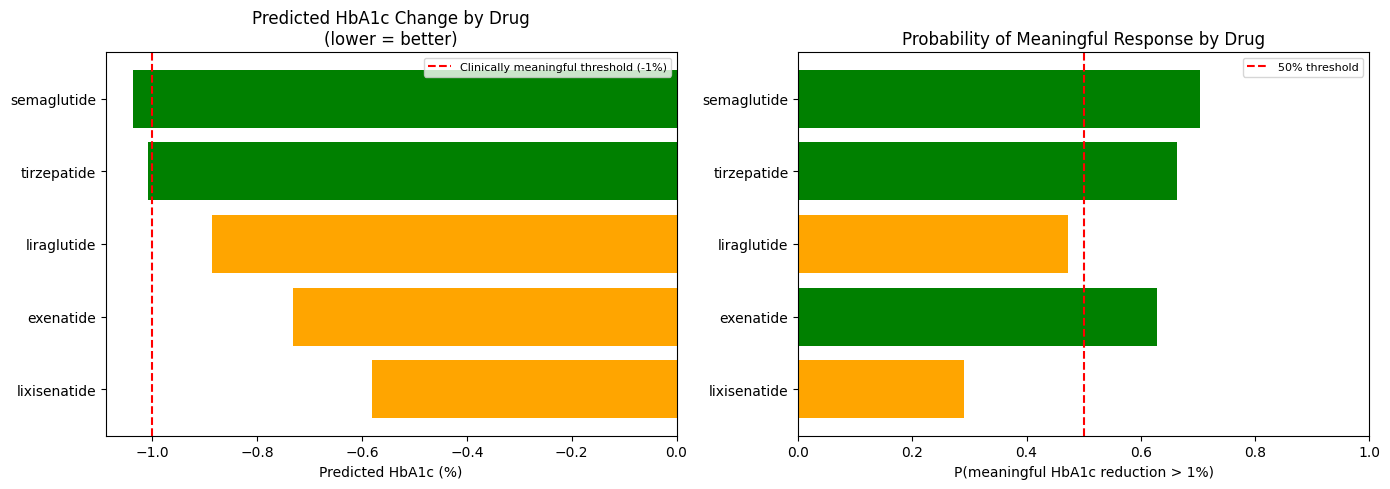

In [ ]:
# --- Example 3: Bar chart of predicted HbA1c by drug ---
import matplotlib.pyplot as plt

colors = ['green' if v < -1.0 else 'orange' for v in results['predicted_delta_hba1c']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression output
axes[0].barh(results['drug_name'], results['predicted_delta_hba1c'], color=colors)
axes[0].axvline(x=-1.0, color='red', linestyle='--', label='Clinically meaningful threshold (-1%)')
axes[0].set_xlabel('Predicted HbA1c (%)')
axes[0].set_title('Predicted HbA1c Change by Drug\n(lower = better)')
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# Classification output
axes[1].barh(results['drug_name'], results['predicted_proba_response'],
             color=['green' if p >= 0.5 else 'orange' for p in results['predicted_proba_response']])
axes[1].axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
axes[1].set_xlabel('P(meaningful HbA1c reduction > 1%)')
axes[1].set_title('Probability of Meaningful Response by Drug')
axes[1].set_xlim(0, 1)
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Step 9 Synthetic Patient Cohort Analysis

In [131]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 100

# Generate realistic T2D patient features 
age              = np.random.normal(58, 10, N).clip(35, 80)
bmi              = np.random.normal(33,  5, N).clip(25, 50)
baseline_hba1c   = np.random.normal(8.5, 1.2, N).clip(7.0, 12.0)
diabetes_duration= np.random.exponential(8, N).clip(1, 25)
weight_kg        = bmi * (1.70 ** 2) * np.random.normal(1, 0.04, N)   # BMI — height²
fasting_glucose  = np.random.normal(9.0, 2.0, N).clip(5.5, 16.0)

# Comorbidities prevalences and age/BMI correlations reflect real T2D populations
has_obesity      = (bmi > 30).astype(int)
has_hypertension = (np.random.rand(N) < np.clip(0.45 + 0.008*(age-50), 0.2, 0.9)).astype(int)
has_cvd          = (np.random.rand(N) < np.clip(0.15 + 0.006*(age-50), 0.05, 0.6)).astype(int)
has_ckd          = (np.random.rand(N) < 0.25).astype(int)
has_dyslipidemia = (np.random.rand(N) < 0.65).astype(int)
has_nafld        = (np.random.rand(N) < np.clip(0.25 + 0.012*(bmi-30), 0.1, 0.7)).astype(int)
has_neuropathy   = (np.random.rand(N) < np.clip(0.08 + 0.018*(diabetes_duration-5), 0.0, 0.6)).astype(int)
has_retinopathy  = (np.random.rand(N) < np.clip(0.04 + 0.012*(diabetes_duration-5), 0.0, 0.4)).astype(int)

synthetic_patients = pd.DataFrame({
    'patient_id':        range(1, N+1),
    'age':               age.round(1),
    'bmi':               bmi.round(1),
    'baseline_hba1c':    baseline_hba1c.round(2),
    'diabetes_duration': diabetes_duration.round(1),
    'weight_kg':         weight_kg.round(1),
    'fasting_glucose':   fasting_glucose.round(2),
    'has_obesity':       has_obesity,
    'has_hypertension':  has_hypertension,
    'has_cvd':           has_cvd,
    'has_ckd':           has_ckd,
    'has_dyslipidemia':  has_dyslipidemia,
    'has_nafld':         has_nafld,
    'has_neuropathy':    has_neuropathy,
    'has_retinopathy':   has_retinopathy,
    'trial_duration_weeks': 26.0,  # fixed â€” standard treatment window
})

print(f"Synthetic cohort: {synthetic_patients.shape}")
print(f"\nPatient summary:")
print(synthetic_patients[['age','bmi','baseline_hba1c','diabetes_duration',
                           'weight_kg','fasting_glucose']].describe().round(2))
print(f"\nComorbidity prevalence (%):")
comorbidity_cols = [c for c in synthetic_patients.columns if c.startswith('has_')]
print((synthetic_patients[comorbidity_cols].mean()*100).round(1).to_string())

# Run all 100 patients — 6 drugs 
drug_mol = drug_features[drug_features['drug_name'].isin(final_df['drug_name'].unique())].copy()
drug_names_list = drug_mol['drug_name'].tolist()

records = []
for _, patient in synthetic_patients.iterrows():
    df_cross = drug_mol.copy()
    for col in synthetic_patients.columns:
        if col != 'patient_id':
            df_cross[col] = patient[col]

    X_cross = df_cross[feature_cols].astype(float)
    delta_preds = reg_model.predict(X_cross)
    proba_preds = clf_model.predict_proba(X_cross)[:, 1]

    for drug, delta, proba in zip(drug_names_list, delta_preds, proba_preds):
        records.append({
            'patient_id':             int(patient['patient_id']),
            'drug_name':              drug,
            'predicted_delta_hba1c':  round(float(delta), 4),
            'predicted_proba_response': round(float(proba), 4),
            **{c: patient[c] for c in synthetic_patients.columns if c != 'patient_id'}
        })

predictions_df = pd.DataFrame(records)

# Tag the best drug per patient (lowest predicted delta = most reduction)
best_drug = (predictions_df.sort_values('predicted_delta_hba1c')
             .groupby('patient_id').first()['drug_name']
             .rename('best_drug'))
predictions_df = predictions_df.merge(best_drug, on='patient_id')

print(f"\nPredictions shape: {predictions_df.shape}  ({N} patients Ã— {len(drug_names_list)} drugs)")
print(f"\nBest drug distribution across {N} patients:")
print(predictions_df.drop_duplicates('patient_id')['best_drug'].value_counts().to_string())
predictions_df.head(6)


Synthetic cohort: (100, 16)

Patient summary:
         age     bmi  baseline_hba1c  diabetes_duration  weight_kg  \
count  100.0  100.00          100.00             100.00     100.00   
mean    57.0   33.13            8.63               8.86      95.51   
std      9.0    4.74            1.15               7.69      13.90   
min     35.0   25.00            7.00               1.00      70.20   
25%     52.0   28.98            7.72               2.78      85.18   
50%     56.7   33.40            8.62               6.45      94.75   
75%     62.1   35.67            9.34              12.68     103.45   
max     76.5   46.60           12.00              25.00     133.50   

       fasting_glucose  
count           100.00  
mean              8.77  
std               1.95  
min               5.50  
25%               7.32  
50%               8.65  
75%              10.08  
max              15.16  

Comorbidity prevalence (%):
has_obesity         70.0
has_hypertension    47.0
has_cvd            

,patient_id,drug_name,predicted_delta_hba1c,predicted_proba_response,age,bmi,baseline_hba1c,diabetes_duration,weight_kg,fasting_glucose,has_obesity,has_hypertension,has_cvd,has_ckd,has_dyslipidemia,has_nafld,has_neuropathy,has_retinopathy,trial_duration_weeks,best_drug
0,1,semaglutide,-1.0887,0.7330,63.0,25.9,8.93,2.7,81.5,15.16,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,tirzepatide
1,1,liraglutide,-0.9881,0.5061,63.0,25.9,8.93,2.7,81.5,15.16,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,tirzepatide
2,1,exenatide,-0.9783,0.6748,63.0,25.9,8.93,2.7,81.5,15.16,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,tirzepatide
3,1,tirzepatide,-1.3687,0.7136,63.0,25.9,8.93,2.7,81.5,15.16,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,tirzepatide
4,1,lixisenatide,-0.8237,0.3085,63.0,25.9,8.93,2.7,81.5,15.16,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,tirzepatide
5,2,semaglutide,-1.0172,0.7553,56.6,30.9,9.17,1.6,86.4,11.24,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,26.0,semaglutide


C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\519960225.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patient_summary, x='best_drug', y='age',
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\519960225.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patient_summary, x='best_drug', y='baseline_hba1c',
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\519960225.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=patient_summary, x='best_drug', y='bmi',


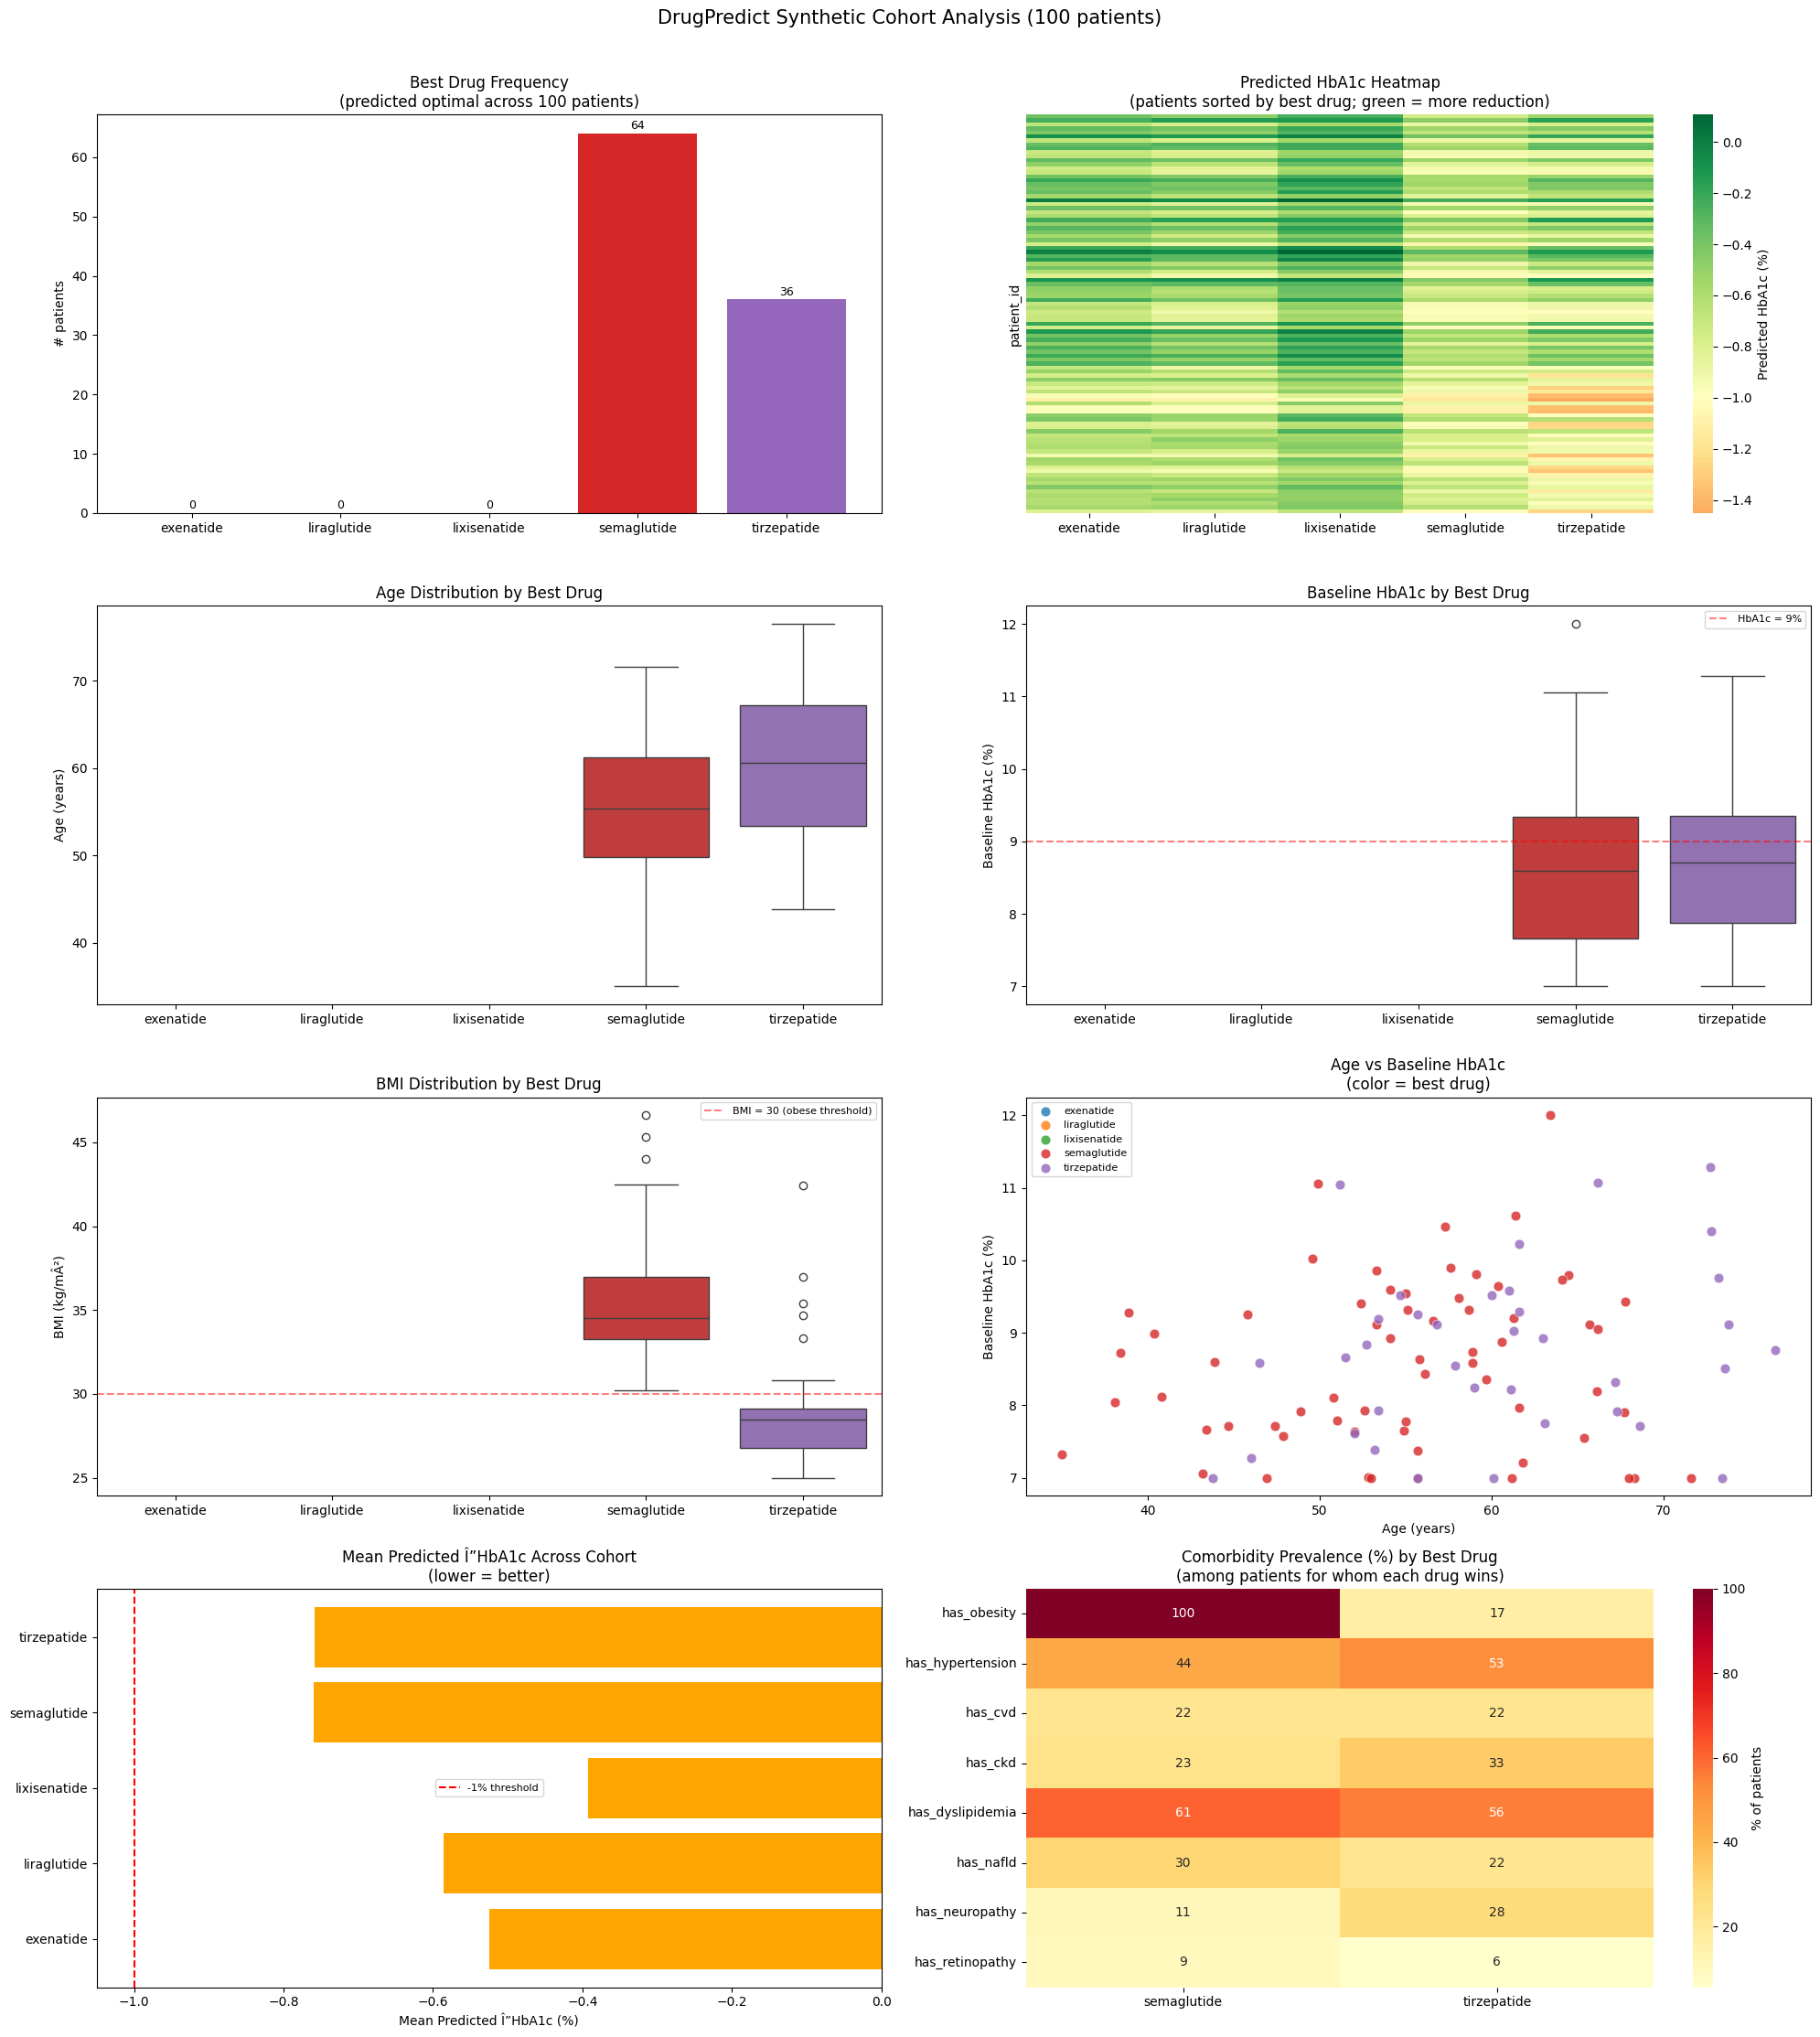

In [134]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

drug_order   = sorted(drug_names_list)
drug_palette = dict(zip(drug_order, sns.color_palette('tab10', len(drug_order))))
patient_summary = predictions_df.drop_duplicates('patient_id').copy()

fig = plt.figure(figsize=(20, 22))
fig.suptitle('DrugPredict Synthetic Cohort Analysis (100 patients)', fontsize=15, y=1.01)

# Plot 1: Best-drug frequency 
ax1 = fig.add_subplot(4, 2, 1)
best_counts = patient_summary['best_drug'].value_counts().reindex(drug_order, fill_value=0)
bars = ax1.bar(best_counts.index, best_counts.values,
               color=[drug_palette[d] for d in best_counts.index])
ax1.set_title('Best Drug Frequency\n(predicted optimal across 100 patients)')
ax1.set_ylabel('# patients')
ax1.set_xlabel('')
for bar, val in zip(bars, best_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=9)

# Plot 2: Predicted delta heatmap (sorted by best drug) 
ax2 = fig.add_subplot(4, 2, 2)
pivot = (predictions_df.pivot(index='patient_id', columns='drug_name',
                               values='predicted_delta_hba1c')
         .loc[patient_summary.sort_values('best_drug')['patient_id']])
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=-1.0,
            cbar_kws={'label': 'Predicted HbA1c (%)'}, yticklabels=False)
ax2.set_title('Predicted HbA1c Heatmap\n(patients sorted by best drug; green = more reduction)')
ax2.set_xlabel('')

# Plot 3: Age distribution by best drug 
ax3 = fig.add_subplot(4, 2, 3)
sns.boxplot(data=patient_summary, x='best_drug', y='age',
            order=drug_order, palette=drug_palette, ax=ax3)
ax3.set_title('Age Distribution by Best Drug')
ax3.set_xlabel('')
ax3.set_ylabel('Age (years)')

# Plot 4: Baseline HbA1c distribution by best drug 
ax4 = fig.add_subplot(4, 2, 4)
sns.boxplot(data=patient_summary, x='best_drug', y='baseline_hba1c',
            order=drug_order, palette=drug_palette, ax=ax4)
ax4.axhline(y=9.0, color='red', linestyle='--', alpha=0.5, label='HbA1c = 9%')
ax4.set_title('Baseline HbA1c by Best Drug')
ax4.set_xlabel('')
ax4.set_ylabel('Baseline HbA1c (%)')
ax4.legend(fontsize=8)

# Plot 5: BMI distribution by best drug 
ax5 = fig.add_subplot(4, 2, 5)
sns.boxplot(data=patient_summary, x='best_drug', y='bmi',
            order=drug_order, palette=drug_palette, ax=ax5)
ax5.axhline(y=30, color='red', linestyle='--', alpha=0.5, label='BMI = 30 (obese threshold)')
ax5.set_title('BMI Distribution by Best Drug')
ax5.set_xlabel('')
ax5.set_ylabel('BMI (kg/mÂ²)')
ax5.legend(fontsize=8)

# Plot 6: Age vs Baseline HbA1c, colored by best drug 
ax6 = fig.add_subplot(4, 2, 6)
for drug in drug_order:
    sub = patient_summary[patient_summary['best_drug'] == drug]
    ax6.scatter(sub['age'], sub['baseline_hba1c'], label=drug,
                color=drug_palette[drug], s=60, alpha=0.8, edgecolors='white', linewidth=0.5)
ax6.set_xlabel('Age (years)')
ax6.set_ylabel('Baseline HbA1c (%)')
ax6.set_title('Age vs Baseline HbA1c\n(color = best drug)')
ax6.legend(fontsize=8, loc='upper left')

# Plot 7: Mean predicted delta by drug across cohort 
ax7 = fig.add_subplot(4, 2, 7)
mean_delta = (predictions_df.groupby('drug_name')['predicted_delta_hba1c']
              .mean().reindex(drug_order))
colors7 = ['green' if v < -1.0 else 'orange' for v in mean_delta]
ax7.barh(mean_delta.index, mean_delta.values, color=colors7)
ax7.axvline(x=-1.0, color='red', linestyle='--', label='-1% threshold')
ax7.set_title('Mean Predicted Î”HbA1c Across Cohort\n(lower = better)')
ax7.set_xlabel('Mean Predicted Î”HbA1c (%)')
ax7.legend(fontsize=8)

# Plot 8: Comorbidity prevalence among patients for whom each drug is best
ax8 = fig.add_subplot(4, 2, 8)
comorbidity_cols = [c for c in patient_summary.columns if c.startswith('has_')]
comorbidity_by_drug = (patient_summary.groupby('best_drug')[comorbidity_cols]
                       .mean() * 100).round(1)
sns.heatmap(comorbidity_by_drug.T, ax=ax8, annot=True, fmt='.0f',
            cmap='YlOrRd', cbar_kws={'label': '% of patients'})
ax8.set_title('Comorbidity Prevalence (%) by Best Drug\n(among patients for whom each drug wins)')
ax8.set_xlabel('')
ax8.set_ylabel('')

plt.tight_layout()
plt.show()


C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = (seg.groupby([seg_col, 'drug_name'])['predicted_delta_hba1c']
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:68: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(seg_col).size()
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

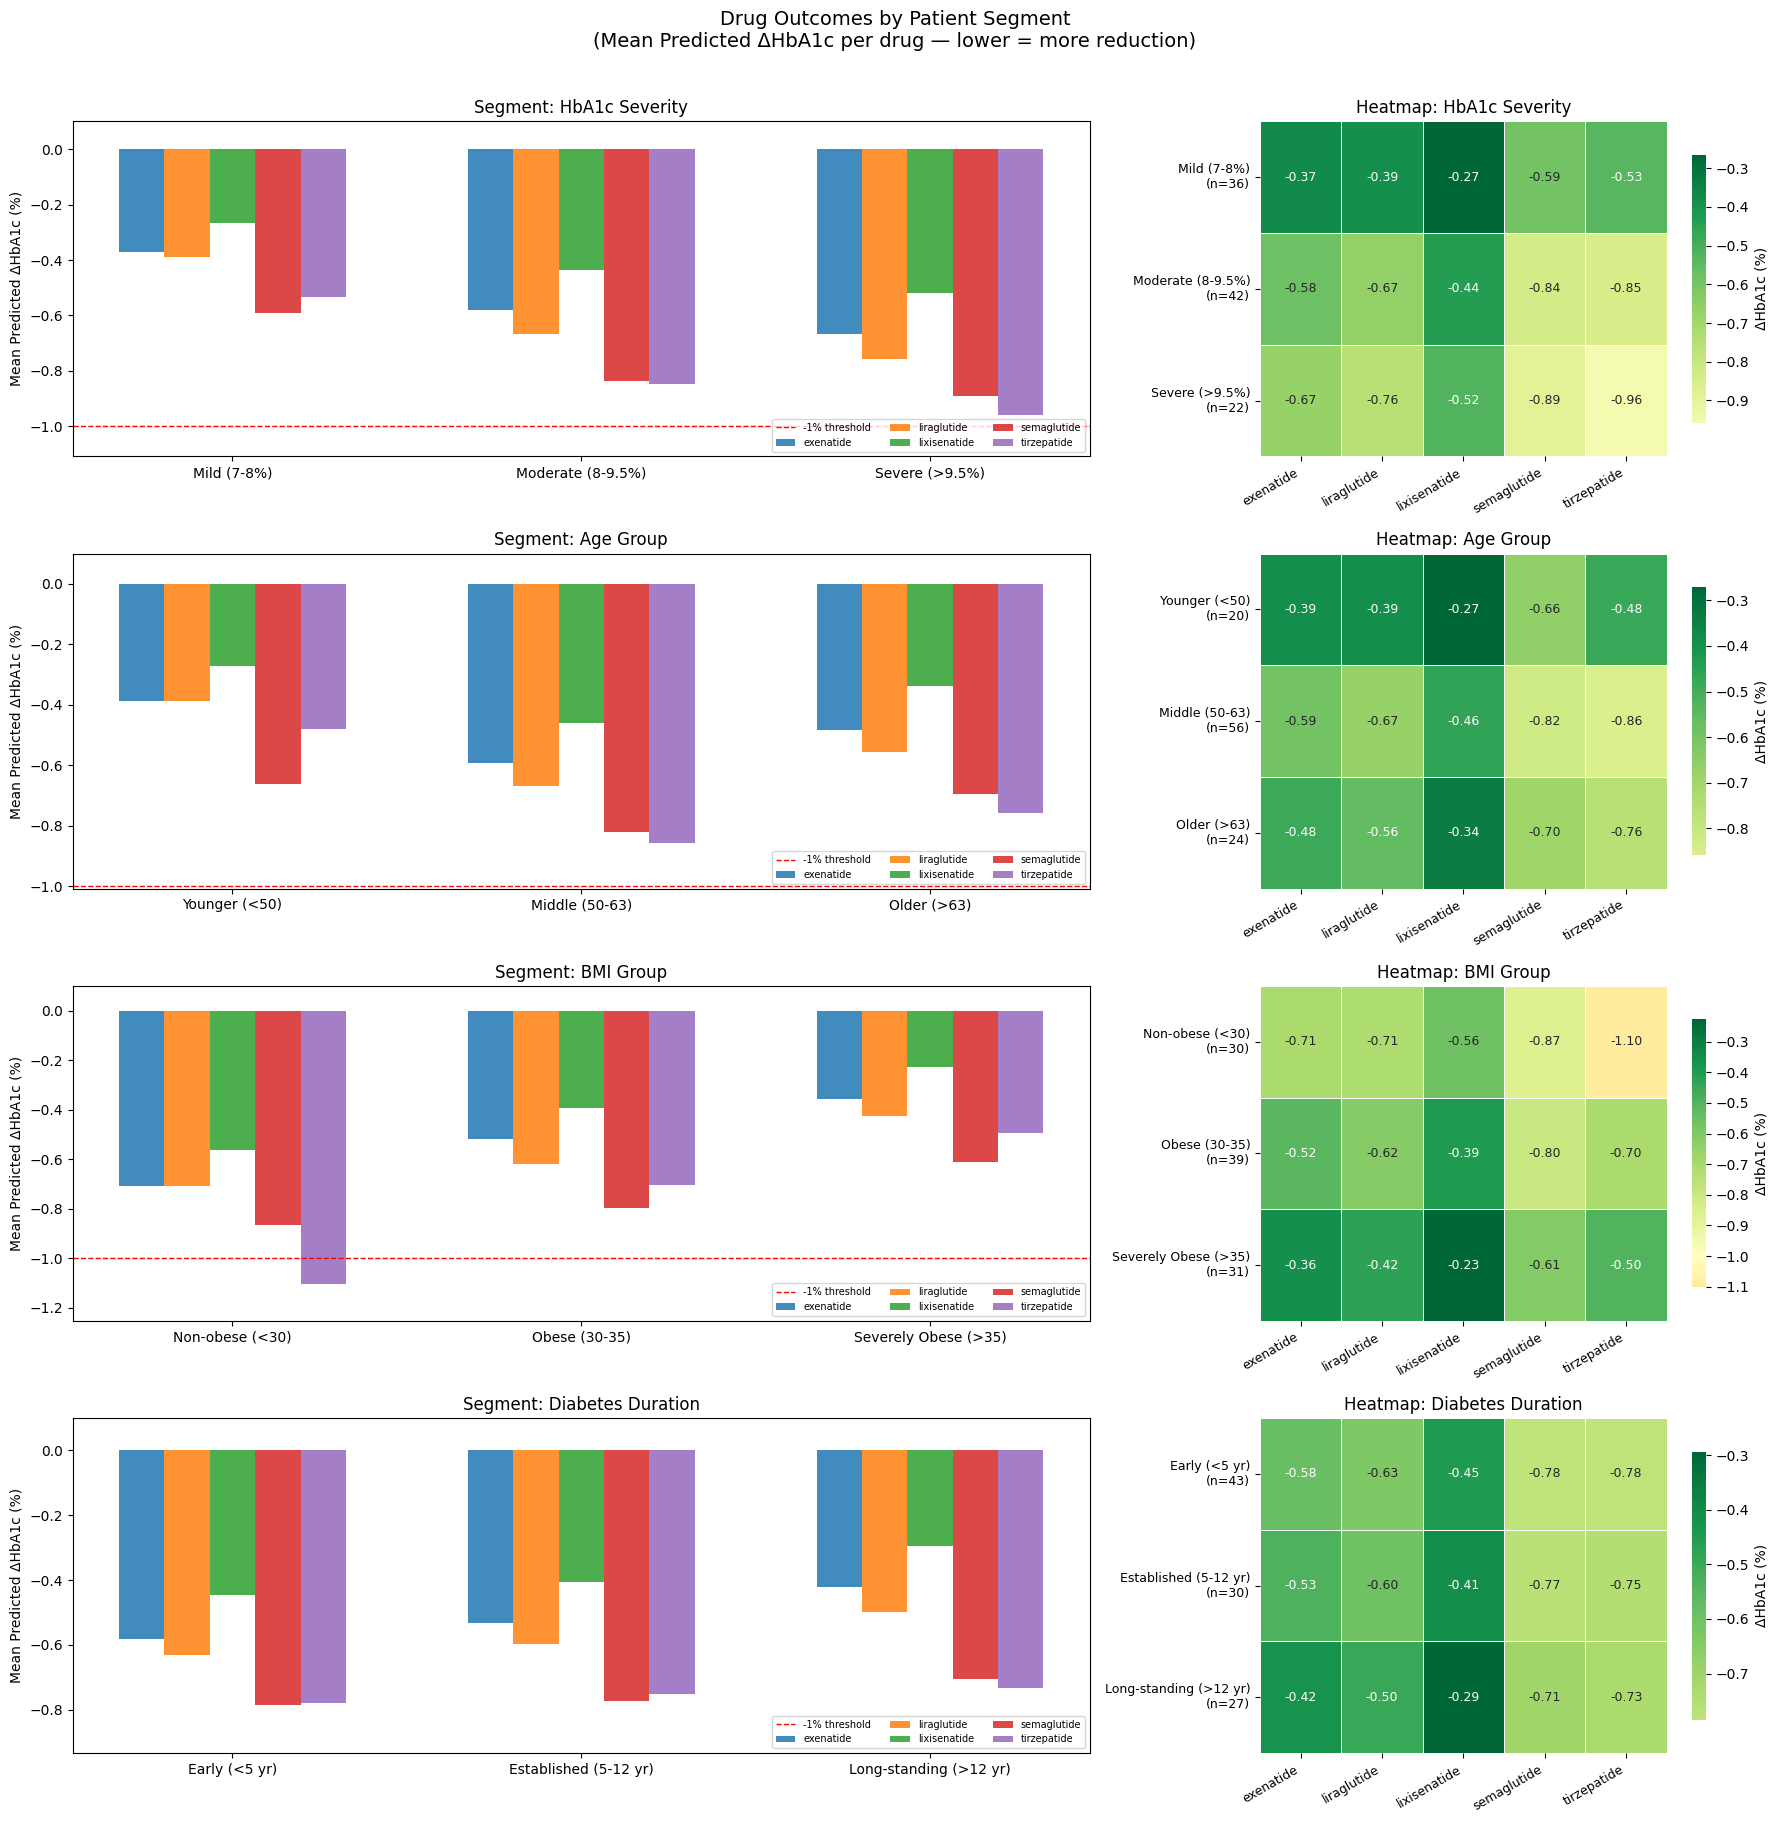


-- Summary tables (mean predicted ΔHbA1c) --

HbA1c Severity:
drug_name          exenatide  liraglutide  lixisenatide  semaglutide  tirzepatide
HbA1c Severity                                                                   
Mild (7-8%)           -0.371       -0.388        -0.265       -0.590       -0.533
Moderate (8-9.5%)     -0.581       -0.666        -0.436       -0.837       -0.847
Severe (>9.5%)        -0.668       -0.756        -0.519       -0.889       -0.958

Age Group:
drug_name       exenatide  liraglutide  lixisenatide  semaglutide  tirzepatide
Age Group                                                                     
Younger (<50)      -0.387       -0.388        -0.271       -0.663       -0.479
Middle (50-63)     -0.592       -0.669        -0.460       -0.822       -0.859
Older (>63)        -0.483       -0.557        -0.339       -0.695       -0.759

BMI Group:
drug_name             exenatide  liraglutide  lixisenatide  semaglutide  tirzepatide
BMI Group              

C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = (seg.groupby([seg_col, 'drug_name'])['predicted_delta_hba1c']
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = (seg.groupby([seg_col, 'drug_name'])['predicted_delta_hba1c']
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\495928260.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ad

In [135]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np

# Define patient segments
seg = predictions_df.copy()

seg['HbA1c Severity'] = pd.cut(
    seg['baseline_hba1c'],
    bins=[0, 8.0, 9.5, 15],
    labels=['Mild (7-8%)', 'Moderate (8-9.5%)', 'Severe (>9.5%)']
)
seg['Age Group'] = pd.cut(
    seg['age'],
    bins=[0, 50, 63, 100],
    labels=['Younger (<50)', 'Middle (50-63)', 'Older (>63)']
)
seg['BMI Group'] = pd.cut(
    seg['bmi'],
    bins=[0, 30, 35, 100],
    labels=['Non-obese (<30)', 'Obese (30-35)', 'Severely Obese (>35)']
)
seg['Diabetes Duration'] = pd.cut(
    seg['diabetes_duration'],
    bins=[0, 5, 12, 30],
    labels=['Early (<5 yr)', 'Established (5-12 yr)', 'Long-standing (>12 yr)']
)

SEGMENTS = ['HbA1c Severity', 'Age Group', 'BMI Group', 'Diabetes Duration']
drug_order = sorted(drug_names_list)

fig, axes = plt.subplots(len(SEGMENTS), 2, figsize=(18, len(SEGMENTS) * 4.5),
                         gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Drug Outcomes by Patient Segment\n(Mean Predicted ΔHbA1c per drug — lower = more reduction)',
             fontsize=14, y=1.01)

for row, seg_col in enumerate(SEGMENTS):
    ax_bar  = axes[row, 0]
    ax_heat = axes[row, 1]   # <-- was missing

    grp = (seg.groupby([seg_col, 'drug_name'])['predicted_delta_hba1c']
              .mean()
              .unstack('drug_name')
              .reindex(columns=drug_order))

    n_segs  = len(grp)
    n_drugs = len(drug_order)
    x       = np.arange(n_segs)
    width   = 0.13
    palette = sns.color_palette('tab10', n_drugs)

    for i, (drug, color) in enumerate(zip(drug_order, palette)):
        offset = (i - n_drugs / 2 + 0.5) * width
        ax_bar.bar(x + offset, grp[drug], width, label=drug, color=color, alpha=0.85)

    ax_bar.axhline(-1.0, color='red', linestyle='--', linewidth=1, label='-1% threshold')
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(grp.index, fontsize=10)
    ax_bar.set_ylabel('Mean Predicted ΔHbA1c (%)')
    ax_bar.set_title(f'Segment: {seg_col}')
    ax_bar.legend(fontsize=7, ncol=3, loc='lower right')
    ax_bar.set_ylim(grp.values.min() - 0.15, 0.1)

    # -- Right: heatmap with n per cell ----------------------------------------
    counts = (seg.drop_duplicates('patient_id')
                 .groupby(seg_col).size()
                 .rename('n'))
    heat_labels = grp.copy().round(2).astype(str)
    for seg_label in grp.index:
        for drug in drug_order:
            val = grp.loc[seg_label, drug]
            heat_labels.loc[seg_label, drug] = f'{val:.2f}'

    sns.heatmap(grp, ax=ax_heat, cmap='RdYlGn', center=-1.0,
                annot=heat_labels, fmt='', annot_kws={'size': 9},
                linewidths=0.5,
                cbar_kws={'label': 'ΔHbA1c (%)', 'shrink': 0.8})

    ylabels = [f'{s}\n(n={counts.get(s, 0)})' for s in grp.index]
    ax_heat.set_yticklabels(ylabels, fontsize=9, rotation=0)
    ax_heat.set_xticklabels(drug_order, rotation=30, ha='right', fontsize=9)
    ax_heat.set_title(f'Heatmap: {seg_col}')
    ax_heat.set_ylabel('')
    ax_heat.set_xlabel('')

plt.tight_layout()
plt.show()

# -- Summary table: mean delta per segment -------------------------------------
print("\n-- Summary tables (mean predicted ΔHbA1c) --\n")
for seg_col in SEGMENTS:
    tbl = (seg.groupby([seg_col, 'drug_name'])['predicted_delta_hba1c']
              .mean().unstack('drug_name').reindex(columns=drug_order).round(3))
    print(f"{seg_col}:")
    print(tbl.to_string())
    print()


# Step 10 Prediction Function for Web App (New Drug via SMILES)

In [170]:
import pickle
import numpy as np
import pandas as pd
import io
import os
import contextlib
from rdkit import Chem
from rdkit.Chem import AllChem
from admet_ai import ADMETModel
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence all RDKit C++ warnings globally
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # silence all RDKit C++ warnings globally

# Load saved artifacts (web app loads these once at startup)
reg_model    = pickle.load(open('../reg_model.pkl',    'rb'))
clf_model    = pickle.load(open('../clf_model.pkl',    'rb'))
feature_cols = pickle.load(open('../feature_cols.pkl', 'rb'))

_admet_model = ADMETModel()   # load once — slow to initialise

import warnings
import logging

@contextlib.contextmanager
def _suppress_output():
    """
    Suppress all output including IPython display events (rich progress widgets).
    Uses IPython capture_output so that display() calls from ADMET-AI/rich
    do not create blank output slots in the notebook.
    RDKit C++ warnings already silenced via RDLogger.DisableLog above.
    """
    from IPython.utils.capture import capture_output as _ipy_capture
    logging.disable(logging.CRITICAL)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            with _ipy_capture(stdout=True, stderr=True, display=True):
                yield
    finally:
        logging.disable(logging.NOTSET)

def predict_from_smiles(smiles: str, patient: dict) -> dict:
    """
    Given a SMILES string for any GLP-1 drug and a patient profile dict,
    return predicted ΔHbA1c and responder probability.

    Parameters
    ----------
    smiles : str
        SMILES notation for the drug (paste from PubChem or ChEMBL)
    patient : dict
        Keys (all optional — missing values handled as NaN by XGBoost):
            baseline_hba1c      float  HbA1c % at baseline  (e.g. 8.5)
            bmi                 float  kg/m²                 (e.g. 32.0)
            age                 float  years                 (e.g. 58.0)
            diabetes_duration   float  years since diagnosis (e.g. 8.0)
            weight_kg           float  kg                    (e.g. 90.0)
            fasting_glucose     float  mmol/L                (e.g. 9.2)
            trial_duration_weeks float weeks of treatment    (e.g. 26.0)
            has_obesity         int    0 or 1
            has_hypertension    int    0 or 1
            has_cvd             int    0 or 1
            has_ckd             int    0 or 1
            has_dyslipidemia    int    0 or 1
            has_nafld           int    0 or 1
            has_neuropathy      int    0 or 1
            has_retinopathy     int    0 or 1

    Returns
    -------
    dict with keys:
        predicted_delta_hba1c      float  e.g. -1.15  (negative = reduction)
        proba_meaningful_response  float  0–1          (P(ΔHbA1c < -1%))
        responder_label            str    'Likely Responder' / 'Unlikely Responder'
        fingerprint_bits_set       int    how many of 2048 bits are active
        smiles_valid               bool
    """
    # 1. Validate SMILES
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {'error': 'Invalid SMILES string - could not parse molecule'}

    # 2 & 3. Fingerprint + ADMET inside suppress block (RDKit logs + Lightning noise)
    with _suppress_output():
        fp          = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        admet_preds = _admet_model.predict(smiles=[smiles])
    fp_dict    = {f'fp_{i}': int(fp[i]) for i in range(2048)}
    admet_dict = admet_preds.iloc[0].to_dict()

    # 4. Combine all features in the exact order the model was trained on
    all_features = {**fp_dict, **admet_dict, **patient}
    X = pd.DataFrame([all_features]).reindex(columns=feature_cols).astype(float)

    # 5. Predict
    delta = float(reg_model.predict(X)[0])
    proba = float(clf_model.predict_proba(X)[0][1])

    return {
        'predicted_delta_hba1c':     round(delta, 3),
        'proba_meaningful_response': round(proba, 3),
        'responder_label':           'Likely Responder' if proba >= 0.5 else 'Unlikely Responder',
        'fingerprint_bits_set':      int(fp.GetNumOnBits()),
        'smiles_valid':              True,
    }


# -- Quick smoke test --------------------------------------------
semaglutide_smiles = drug_df[drug_df['drug_name'] == 'semaglutide']['smiles'].values[0]

result = predict_from_smiles(
    smiles=semaglutide_smiles,
    patient={
        'baseline_hba1c':       8.5,
        'bmi':                  32.0,
        'age':                  58.0,
        'diabetes_duration':    8.0,
        'weight_kg':            90.0,
        'fasting_glucose':      9.2,
        'trial_duration_weeks': 26.0,
        'has_obesity':          1,
        'has_hypertension':     1,
        'has_cvd':              0,
        'has_ckd':              0,
        'has_dyslipidemia':     1,
        'has_nafld':            0,
        'has_neuropathy':       0,
        'has_retinopathy':      0,
    }
)

print("Smoke test - semaglutide, typical T2D patient:")
for k, v in result.items():
    print(f"  {k}: {v}")


Smoke test - semaglutide, typical T2D patient:
  predicted_delta_hba1c: -1.042
  proba_meaningful_response: 0.711
  responder_label: Likely Responder
  fingerprint_bits_set: 156
  smiles_valid: True


# Step 11 Demo Drug Dropdown (Pre-loaded SMILES for Web App)

In [174]:
import pickle
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# -- Demo drug catalog -------------------------------------------------------
# Albiglutide excluded: it is a GLP-1/albumin fusion protein (~73 kDa) that
# cannot be represented by a single SMILES string. All 5 remaining drugs
# verified by RDKit ExactMolWt vs. literature values (within 3 Da tolerance).

smiles_lookup = dict(zip(drug_df['drug_name'], drug_df['smiles']))

DEMO_DRUGS = [
    {
        'label':      'Semaglutide (Ozempic / Wegovy)',
        'drug_name':  'semaglutide',
        'generation': '2nd-gen GLP-1 agonist - weekly SC injection',
        'notes':      'Modified GLP-1 with C18 fatty acid chain for albumin binding; longest half-life peptide GLP-1',
        'smiles':     smiles_lookup['semaglutide'],
    },
    {
        'label':      'Tirzepatide (Mounjaro / Zepbound)',
        'drug_name':  'tirzepatide',
        'generation': 'Dual GLP-1 / GIP agonist - weekly SC injection',
        'notes':      'First dual incretin agonist; GIP co-agonism adds weight loss on top of glycemic control',
        'smiles':     smiles_lookup['tirzepatide'],
    },
    {
        'label':      'Liraglutide (Victoza / Saxenda)',
        'drug_name':  'liraglutide',
        'generation': '1st-gen GLP-1 agonist - daily SC injection',
        'notes':      'C16 fatty acid attached via linker; first GLP-1 agonist approved for T2D',
        'smiles':     smiles_lookup['liraglutide'],
    },
    {
        'label':      'Exenatide (Byetta / Bydureon)',
        'drug_name':  'exenatide',
        'generation': '1st-gen GLP-1 agonist - twice-daily or weekly SC injection',
        'notes':      'Synthetic exendin-4 from Gila monster venom; shorter half-life than human GLP-1 analogs',
        'smiles':     smiles_lookup['exenatide'],
    },
    {
        'label':      'Lixisenatide (Adlyxin / Lyxumia)',
        'drug_name':  'lixisenatide',
        'generation': '1st-gen GLP-1 agonist - daily SC injection',
        'notes':      'Modified exendin-4 with 6 Lys residues added; predominantly post-meal glucose lowering',
        'smiles':     smiles_lookup['lixisenatide'],
    },
]

demo_df = pd.DataFrame(DEMO_DRUGS)

# -- Show catalog --------------------------------------------------------------
print("Demo drug catalog (5 drugs, albiglutide excluded - no valid SMILES for fusion protein):\n")
print(demo_df[['label', 'generation']].to_string(index=False))

# -- Jaccard fingerprint similarity --------------------------------------------
print("\n-- Jaccard fingerprint similarity between demo drugs --")
fps = []
for row in DEMO_DRUGS:
    mol = Chem.MolFromSmiles(row['smiles'])
    fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))

names = [d['drug_name'] for d in DEMO_DRUGS]
sim_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for i, fp1 in enumerate(fps):
    for j, fp2 in enumerate(fps):
        sim_matrix.iloc[i, j] = round(DataStructs.TanimotoSimilarity(fp1, fp2), 3)
print(sim_matrix.to_string())

# -- Save demo catalog for the web app ----------------------------------------
with open('../demo_drugs.pkl', 'wb') as f:
    pickle.dump(DEMO_DRUGS, f)
print("\nSaved demo_drugs.pkl  (5 drugs)")


Demo drug catalog (5 drugs, albiglutide excluded - no valid SMILES for fusion protein):

                            label                                                 generation
   Semaglutide (Ozempic / Wegovy)                2nd-gen GLP-1 agonist - weekly SC injection
Tirzepatide (Mounjaro / Zepbound)             Dual GLP-1 / GIP agonist - weekly SC injection
  Liraglutide (Victoza / Saxenda)                 1st-gen GLP-1 agonist - daily SC injection
    Exenatide (Byetta / Bydureon) 1st-gen GLP-1 agonist - twice-daily or weekly SC injection
 Lixisenatide (Adlyxin / Lyxumia)                 1st-gen GLP-1 agonist - daily SC injection

-- Jaccard fingerprint similarity between demo drugs --
              semaglutide  tirzepatide  liraglutide  exenatide  lixisenatide
semaglutide         1.000        0.719        0.844      0.596         0.536
tirzepatide         0.719        1.000        0.597      0.678         0.663
liraglutide         0.844        0.597        1.000      0.643   

Demo predictions - standard T2D patient (HbA1c=8.5%, BMI=32, Age=58):

                             Drug                                                 Generation  dHbA1c (pred)  P(responder)            Outcome  Bits set (/ 2048)
   Semaglutide (Ozempic / Wegovy)                2nd-gen GLP-1 agonist - weekly SC injection         -1.042         0.711   Likely Responder                156
Tirzepatide (Mounjaro / Zepbound)             Dual GLP-1 / GIP agonist - weekly SC injection         -0.996         0.655   Likely Responder                174
  Liraglutide (Victoza / Saxenda)                 1st-gen GLP-1 agonist - daily SC injection         -0.885         0.478 Unlikely Responder                139
    Exenatide (Byetta / Bydureon) 1st-gen GLP-1 agonist - twice-daily or weekly SC injection         -0.707         0.628   Likely Responder                160
 Lixisenatide (Adlyxin / Lyxumia)                 1st-gen GLP-1 agonist - daily SC injection         -0.584         0.316 Unlikel

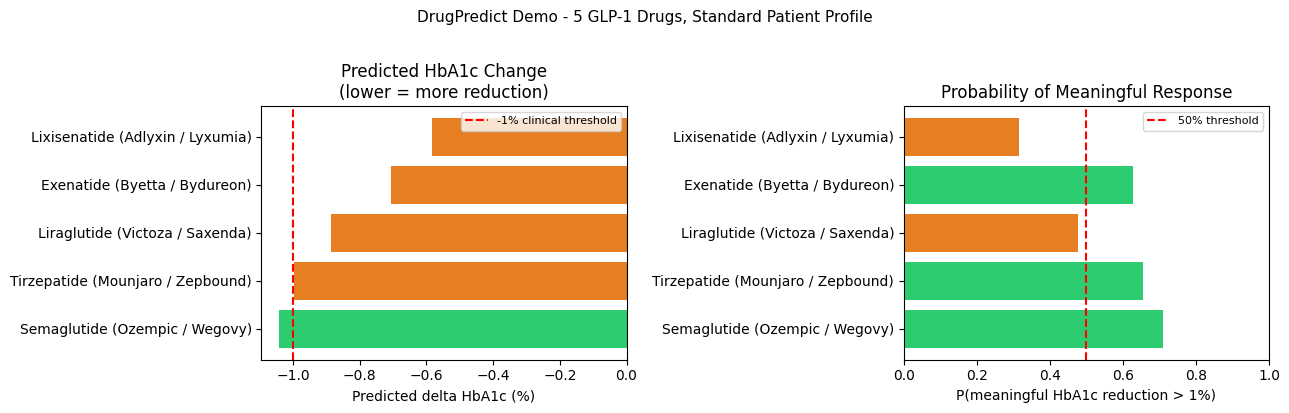

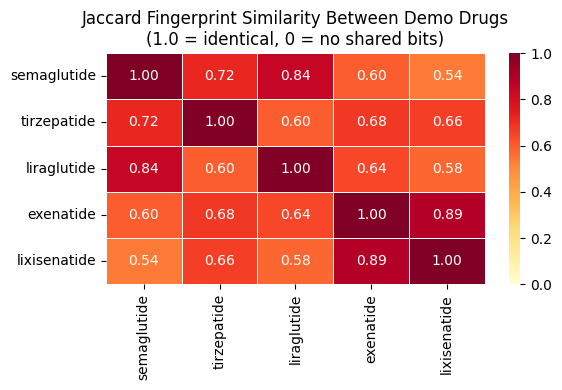

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

# -- Run all 5 demo drugs through the model for a standard patient ------------
demo_patient = {
    'baseline_hba1c':       8.5,
    'bmi':                  32.0,
    'age':                  58.0,
    'diabetes_duration':    8.0,
    'weight_kg':            90.0,
    'fasting_glucose':      9.2,
    'trial_duration_weeks': 26.0,
    'has_obesity':          1,
    'has_hypertension':     1,
    'has_cvd':              0,
    'has_ckd':              0,
    'has_dyslipidemia':     1,
    'has_nafld':            0,
    'has_neuropathy':       0,
    'has_retinopathy':      0,
}

demo_results = []
for drug in DEMO_DRUGS:
    out = predict_from_smiles(drug['smiles'], demo_patient)
    demo_results.append({
        'Drug':              drug['label'],
        'Generation':        drug['generation'],
        'delta_hba1c':       out['predicted_delta_hba1c'],
        'p_responder':       out['proba_meaningful_response'],
        'Outcome':           out['responder_label'],
        'Bits set (/ 2048)': out['fingerprint_bits_set'],
    })

results_df = pd.DataFrame(demo_results).sort_values('delta_hba1c')
print("Demo predictions - standard T2D patient (HbA1c=8.5%, BMI=32, Age=58):\n")
print(results_df.rename(columns={'delta_hba1c': 'dHbA1c (pred)', 'p_responder': 'P(responder)'})
      .to_string(index=False))

# -- Visualise ----------------------------------------------------------------
fig_demo, ax_demo = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#2ecc71' if v < -1.0 else '#e67e22' for v in results_df['delta_hba1c']]
ax_demo[0].barh(results_df['Drug'], results_df['delta_hba1c'], color=colors)
ax_demo[0].axvline(-1.0, color='red', linestyle='--', label='-1% clinical threshold')
ax_demo[0].set_xlabel('Predicted delta HbA1c (%)')
ax_demo[0].set_title('Predicted HbA1c Change\n(lower = more reduction)')
ax_demo[0].legend(fontsize=8)

colors2 = ['#2ecc71' if p >= 0.5 else '#e67e22' for p in results_df['p_responder']]
ax_demo[1].barh(results_df['Drug'], results_df['p_responder'], color=colors2)
ax_demo[1].axvline(0.5, color='red', linestyle='--', label='50% threshold')
ax_demo[1].set_xlabel('P(meaningful HbA1c reduction > 1%)')
ax_demo[1].set_title('Probability of Meaningful Response')
ax_demo[1].set_xlim(0, 1)
ax_demo[1].legend(fontsize=8)

plt.suptitle('DrugPredict Demo - 5 GLP-1 Drugs, Standard Patient Profile',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# -- Similarity heatmap -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(6, 4))
short_names = [d['drug_name'] for d in DEMO_DRUGS]
sns.heatmap(sim_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=short_names, yticklabels=short_names, ax=ax2,
            vmin=0, vmax=1, linewidths=0.5)
ax2.set_title('Jaccard Fingerprint Similarity Between Demo Drugs\n(1.0 = identical, 0 = no shared bits)')
plt.tight_layout()
plt.show()


## Step 12: Novel GLP-1 Drug Candidates — Predicted Efficacy

Three hypothetical candidates are generated by programmatically modifying the fatty acid chain of approved drugs using RDKit reaction SMARTS. Fatty acid length is the primary handle for tuning albumin-binding affinity and plasma half-life in this drug class.

| Candidate | Base Drug | Modification | Rationale |
|-----------|-----------|--------------|-----------|
| **SemaC20** | Semaglutide | C18 → C20 diacid (+2 CH₂) | Stronger albumin binding → potential monthly SC dosing |
| **LiraC18** | Liraglutide | C16 → C18 monoacid (palmitoyl → stearoyl) | Extended half-life from ~13 h toward 24–48 h |
| **TirzC22** | Tirzepatide | C20 → C22 diacid (+2 CH₂) | Bi-weekly/monthly potential on dual GLP-1/GIP scaffold |


Generating proposed drug candidates...

  SemaC20     base=semaglutide   base_MW=4111.1  mod_MW=4139.1  dMW=+28.0 Da  [OK (+28 Da)]
  LiraC18     base=liraglutide   base_MW=3748.9  mod_MW=3777.0  dMW=+28.0 Da  [OK (+28 Da)]
  TirzC22     base=tirzepatide   base_MW=4810.5  mod_MW=4838.6  dMW=+28.0 Da  [OK (+28 Da)]

Expected delta per +2 CH₂ groups: +28.031 Da

All drugs — standard patient (HbA1c=8.5%, BMI=32, Age=58):

        Drug    Based on                              Modification  dHbA1c  P(resp)            Outcome
 semaglutide  (approved)                                         —  -1.042    0.711   Likely Responder
     SemaC20 semaglutide                 C18 → C20 diacid (+2 CH₂)  -1.039    0.706   Likely Responder
     TirzC22 tirzepatide                 C20 → C22 diacid (+2 CH₂)  -0.997    0.649   Likely Responder
 tirzepatide  (approved)                                         —  -0.996    0.655   Likely Responder
     LiraC18 liraglutide C16 → C18 monoacid (palmitoyl → stear

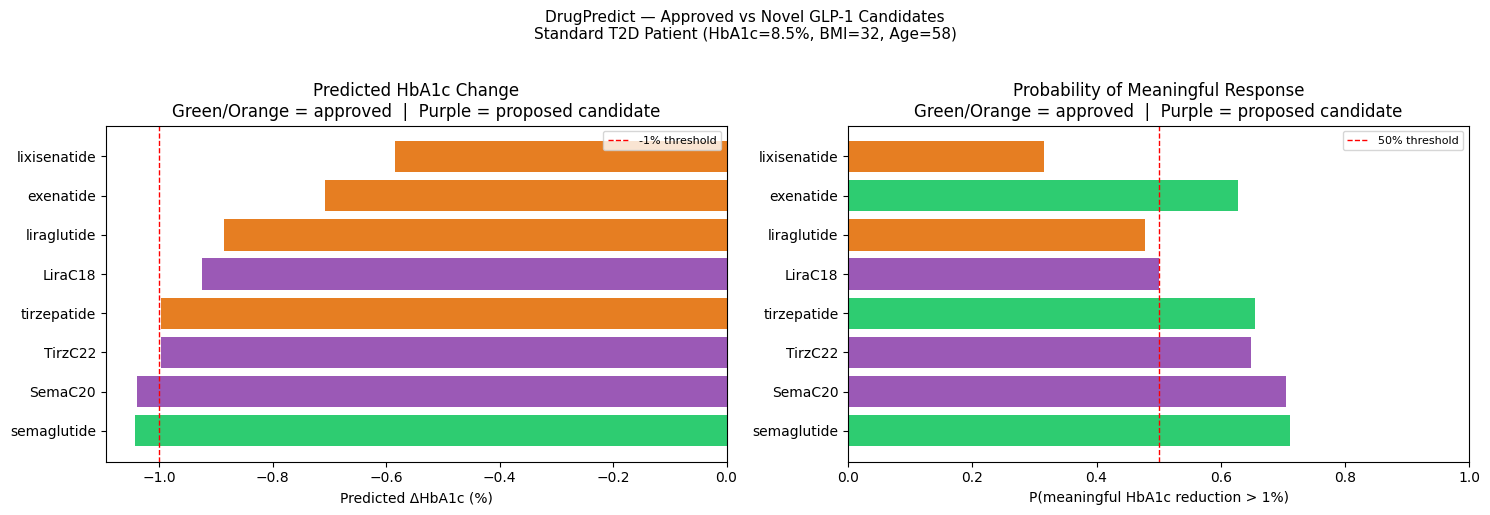


Jaccard similarity of each candidate to its base drug:
  SemaC20    vs semaglutide   Tanimoto = 1.0000
  LiraC18    vs liraglutide   Tanimoto = 1.0000
  TirzC22    vs tirzepatide   Tanimoto = 1.0000


In [173]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Helper: apply a SMARTS reaction, return canonical SMILES of first product ─
def modify_smiles(base_smiles, rxn_smarts, name):
    rxn = AllChem.ReactionFromSmarts(rxn_smarts)
    mol = Chem.MolFromSmiles(base_smiles)
    products = rxn.RunReactants((mol,))
    if not products:
        raise ValueError(f"[{name}] Reaction produced no products — check SMARTS pattern.")
    prod = products[0][0]
    Chem.SanitizeMol(prod)
    return Chem.MolToSmiles(prod)

base_smiles = dict(zip(drug_df['drug_name'], drug_df['smiles']))

# ── Reaction SMARTS for each modification ─────────────────────────────────────
# C18 diacid (semaglutide): HOOC-(CH2)16-COOH → 16 inner CH2 groups between two C=O
# C20 diacid target:        HOOC-(CH2)18-COOH → 18 inner CH2 groups
SEMA_C20 = ('[C:1](=O)CCCCCCCCCCCCCCCC[C:2](=O)'    # 16 CH2 (C18 diacid)
            '>>'
            '[C:1](=O)CCCCCCCCCCCCCCCCCC[C:2](=O)')  # 18 CH2 (C20 diacid)

# C16 monoacid (liraglutide): CH3-(CH2)14-C(=O) → 14 CH2 + terminal CH3
# C18 monoacid target:        CH3-(CH2)16-C(=O) → 16 CH2 + terminal CH3
LIRA_C18 = ('[C:1](=O)CCCCCCCCCCCCCC[CH3:2]'    # 14 CH2 → CH3 (C16 palmitate)
            '>>'
            '[C:1](=O)CCCCCCCCCCCCCCCC[CH3:2]')  # 16 CH2 → CH3 (C18 stearate)

# C20 diacid (tirzepatide): HOOC-(CH2)18-COOH → 18 inner CH2 groups
# C22 diacid target:        HOOC-(CH2)20-COOH → 20 inner CH2 groups
TIRZ_C22 = ('[C:1](=O)CCCCCCCCCCCCCCCCCC[C:2](=O)'    # 18 CH2 (C20 diacid)
            '>>'
            '[C:1](=O)CCCCCCCCCCCCCCCCCCCC[C:2](=O)')  # 20 CH2 (C22 diacid)

candidates_meta = [
    dict(name='SemaC20', base='semaglutide', smarts=SEMA_C20,
         modification='C18 → C20 diacid (+2 CH₂)',
         rationale='Stronger albumin binding → potential monthly SC dosing'),
    dict(name='LiraC18', base='liraglutide', smarts=LIRA_C18,
         modification='C16 → C18 monoacid (palmitoyl → stearoyl)',
         rationale='Extended plasma half-life toward 24–48 h'),
    dict(name='TirzC22', base='tirzepatide', smarts=TIRZ_C22,
         modification='C20 → C22 diacid (+2 CH₂)',
         rationale='Bi-weekly/monthly potential on dual GLP-1/GIP scaffold'),
]

# ── Generate, validate, and print MW delta ────────────────────────────────────
print("Generating proposed drug candidates...\n")
PROPOSED_DRUGS = []
for c in candidates_meta:
    base_mw  = rdMolDescriptors.CalcExactMolWt(Chem.MolFromSmiles(base_smiles[c['base']]))
    mod_smi  = modify_smiles(base_smiles[c['base']], c['smarts'], c['name'])
    mod_mw   = rdMolDescriptors.CalcExactMolWt(Chem.MolFromSmiles(mod_smi))
    delta_mw = mod_mw - base_mw
    status   = "OK (+28 Da)" if 27.5 < delta_mw < 28.5 else f"WARNING: unexpected delta {delta_mw:+.1f} Da"
    print(f"  {c['name']:10s}  base={c['base']:12s}  base_MW={base_mw:.1f}  mod_MW={mod_mw:.1f}  dMW={delta_mw:+.1f} Da  [{status}]")
    PROPOSED_DRUGS.append({**c, 'smiles': mod_smi, 'base_mw': base_mw, 'mod_mw': mod_mw})

print("\nExpected delta per +2 CH₂ groups: +28.031 Da")

# ── Standard patient ──────────────────────────────────────────────────────────
std_patient = {
    'baseline_hba1c': 8.5, 'bmi': 32.0, 'age': 58.0, 'diabetes_duration': 8.0,
    'weight_kg': 90.0, 'fasting_glucose': 9.2, 'trial_duration_weeks': 26.0,
    'has_obesity': 1, 'has_hypertension': 1, 'has_cvd': 0, 'has_ckd': 0,
    'has_dyslipidemia': 1, 'has_nafld': 0, 'has_neuropathy': 0, 'has_retinopathy': 0,
}

# ── Predictions: proposed candidates ─────────────────────────────────────────
proposed_preds = []
for drug in PROPOSED_DRUGS:
    out = predict_from_smiles(drug['smiles'], std_patient)
    proposed_preds.append({
        'Drug':         drug['name'],
        'Based on':     drug['base'],
        'Modification': drug['modification'],
        'delta_hba1c':  out['predicted_delta_hba1c'],
        'p_responder':  out['proba_meaningful_response'],
        'Outcome':      out['responder_label'],
        'is_proposed':  True,
    })

# ── Predictions: approved drugs (for comparison) ─────────────────────────────
approved_preds = []
for drug in DEMO_DRUGS:
    out = predict_from_smiles(drug['smiles'], std_patient)
    approved_preds.append({
        'Drug':         drug['drug_name'],
        'Based on':     '(approved)',
        'Modification': '—',
        'delta_hba1c':  out['predicted_delta_hba1c'],
        'p_responder':  out['proba_meaningful_response'],
        'Outcome':      out['responder_label'],
        'is_proposed':  False,
    })

all_preds = pd.DataFrame(approved_preds + proposed_preds).sort_values('delta_hba1c')

print("\nAll drugs — standard patient (HbA1c=8.5%, BMI=32, Age=58):\n")
print(all_preds[['Drug','Based on','Modification','delta_hba1c','p_responder','Outcome']]
      .rename(columns={'delta_hba1c':'dHbA1c','p_responder':'P(resp)'})
      .to_string(index=False))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig12, ax12 = plt.subplots(1, 2, figsize=(15, 5))

bar_colors = ['#9b59b6' if row['is_proposed'] else ('#2ecc71' if row['delta_hba1c'] < -1.0 else '#e67e22')
              for _, row in all_preds.iterrows()]

ax12[0].barh(all_preds['Drug'], all_preds['delta_hba1c'], color=bar_colors)
ax12[0].axvline(-1.0, color='red', linestyle='--', linewidth=1, label='-1% threshold')
ax12[0].set_xlabel('Predicted ΔHbA1c (%)')
ax12[0].set_title('Predicted HbA1c Change\nGreen/Orange = approved  |  Purple = proposed candidate')
ax12[0].legend(fontsize=8)

bar_colors2 = ['#9b59b6' if row['is_proposed'] else ('#2ecc71' if row['p_responder'] >= 0.5 else '#e67e22')
               for _, row in all_preds.iterrows()]
ax12[1].barh(all_preds['Drug'], all_preds['p_responder'], color=bar_colors2)
ax12[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax12[1].set_xlabel('P(meaningful HbA1c reduction > 1%)')
ax12[1].set_title('Probability of Meaningful Response\nGreen/Orange = approved  |  Purple = proposed candidate')
ax12[1].set_xlim(0, 1)
ax12[1].legend(fontsize=8)

plt.suptitle('DrugPredict — Approved vs Novel GLP-1 Candidates\nStandard T2D Patient (HbA1c=8.5%, BMI=32, Age=58)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── Fingerprint similarity of candidates to their base drugs ─────────────────
from rdkit.Chem import DataStructs
print("\nJaccard similarity of each candidate to its base drug:")
for drug in PROPOSED_DRUGS:
    mol_base = Chem.MolFromSmiles(base_smiles[drug['base']])
    mol_cand = Chem.MolFromSmiles(drug['smiles'])
    fp_base  = AllChem.GetMorganFingerprintAsBitVect(mol_base, radius=2, nBits=2048)
    fp_cand  = AllChem.GetMorganFingerprintAsBitVect(mol_cand, radius=2, nBits=2048)
    sim = DataStructs.TanimotoSimilarity(fp_base, fp_cand)
    print(f"  {drug['name']:10s} vs {drug['base']:12s}  Tanimoto = {sim:.4f}")


## Step 13: Structurally Distinct Novel GLP-1 Candidates

Step 12 extended fatty acid chains by +2 CH₂ — minor changes that leave the fingerprint nearly identical to the base drug. Step 13 applies qualitatively different modifications that introduce entirely new atom types and ring systems, creating substantially different Morgan fingerprint bits.

| Candidate | Base Drug | Modification | Design Rationale |
|-----------|-----------|--------------|-----------------|
| **LiraBenzyl** | Liraglutide | C16 terminal CH₃ → benzyl (–CH₂Ph) | Aromatic terminus: novel lipophilic binding pocket interactions; many new ring bits |
| **SemaPiperi** | Semaglutide | C18 diacid free COOH → N-piperidyl amide | Saturated N-heterocycle: altered polarity, caps free acid, new ring/N fingerprint bits |
| **TirzDiF** | Tirzepatide | C20 diacid alpha-CH₂ → gem-CF₂ | Bioisosteric difluoro: metabolic stabilization via blocked oxidation; unique F-bearing bits |

> **Note:** These are in-silico hypothetical candidates. The model was trained on approved GLP-1 peptides — predictions for structurally novel groups (aromatic rings, F atoms) are extrapolations and should be interpreted as directional estimates only.


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors, DataStructs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def modify_smiles(base_smiles, rxn_smarts, name):
    """Apply a SMARTS reaction, return canonical SMILES of the first product."""
    rxn = AllChem.ReactionFromSmarts(rxn_smarts)
    mol = Chem.MolFromSmiles(base_smiles)
    products = rxn.RunReactants((mol,))
    if not products:
        raise ValueError(f"[{name}] No products — check SMARTS pattern.")
    prod = products[0][0]
    Chem.SanitizeMol(prod)
    return Chem.MolToSmiles(prod)

base_smiles = dict(zip(drug_df['drug_name'], drug_df['smiles']))

# ── Reaction SMARTS ────────────────────────────────────────────────────────────

# Candidate A — LiraBenzyl
# Liraglutide: C16 fatty monoacid CH3-(CH2)14-C(=O)-[peptide linker]
# The terminal CH3 is 14 bonds from the carbonyl, so we can't anchor on C=O.
# Instead match the terminal 3-carbon chain: CH3-CH2-CH2 (end of long fatty chain).
# Amino acid side chains never have CH3-CH2-CH2 in a linear sequence, so this is unique.
# Change: terminal CH3 → benzyl (−CH2Ph), adding a phenyl ring to the lipid end.
# ΔMW ≈ +76 Da  (CH3 15 Da → CH2Ph 91 Da)
LIRA_BENZYL = (
    '[CH3:1][CH2:2][CH2:3]'
    '>>'
    '[CH2:1](c1ccccc1)[CH2:2][CH2:3]'
)

# Candidate B — SemaPiperi
# Semaglutide: C18 diacid HOOC-(CH2)16-C(=O)-[linker]
# The 16 inner CH2s uniquely identify this free-COOH end within the molecule.
# Change: free COOH → N-piperidyl amide, capping the acid with a saturated N-heterocycle.
# ΔMW ≈ +66 Da  (−OH 17 Da + piperidine-N fragment 83 Da)
SEMA_PIPERI = (
    '[OH:1][C:2](=O)CCCCCCCCCCCCCCCC[C:3](=O)'       # HOOC-(CH2)16-C=O
    '>>'
    '[N:1]1CCCCC1[C:2](=O)CCCCCCCCCCCCCCCC[C:3](=O)' # N-piperidyl amide
)

# Candidate C — TirzDiF
# Tirzepatide: C20 diacid HOOC-(CH2)18-C(=O)-[linker]
# [CH2:3] = alpha carbon + 17 more CH2s = 18 inner carbons total (C20 diacid).
# Change: alpha-CH2 → gem-CF2 (bioisosteric fluorination).
# ΔMW ≈ +36 Da  (2H → 2F: each +18.0 − 1.0 = +17 Da × 2 = +36 Da)
TIRZ_DIF = (
    '[OH:1][C:2](=O)[CH2:3]CCCCCCCCCCCCCCCCC[C:4](=O)'      # alpha-CH2, C20 diacid
    '>>'
    '[OH:1][C:2](=O)[C:3](F)(F)CCCCCCCCCCCCCCCCC[C:4](=O)'  # alpha-CF2
)

candidates_meta = [
    dict(name='LiraBenzyl', base='liraglutide', smarts=LIRA_BENZYL,
         modification='C16 terminal CH₃ → benzyl (–CH₂Ph)',
         expected_dmw=+76.1),
    dict(name='SemaPiperi', base='semaglutide', smarts=SEMA_PIPERI,
         modification='C18 diacid COOH → N-piperidyl amide',
         expected_dmw=+66.1),
    dict(name='TirzDiF',   base='tirzepatide', smarts=TIRZ_DIF,
         modification='C20 diacid alpha-CH₂ → gem-CF₂',
         expected_dmw=+36.0),
]

# ── Generate, validate MW, count new fingerprint bits ─────────────────────────
print("Generating structurally distinct novel candidates...\n")
NOVEL_DRUGS = []
for c in candidates_meta:
    base_mw  = rdMolDescriptors.CalcExactMolWt(Chem.MolFromSmiles(base_smiles[c['base']]))
    mod_smi  = modify_smiles(base_smiles[c['base']], c['smarts'], c['name'])
    mod_mw   = rdMolDescriptors.CalcExactMolWt(Chem.MolFromSmiles(mod_smi))
    delta_mw = mod_mw - base_mw
    ok = abs(delta_mw - c['expected_dmw']) < 5
    print(f"  {c['name']:12s}  dMW={delta_mw:+.1f} Da (expected ~{c['expected_dmw']:+.1f})  "
          f"{'OK' if ok else 'WARNING - unexpected delta'}")
    NOVEL_DRUGS.append({**c, 'smiles': mod_smi})

# ── Fingerprint divergence from base drugs ────────────────────────────────────
print("\nFingerprint divergence vs base drug (ECFP4, 2048 bits):")
print(f"  {'Candidate':12s}  {'Base':12s}  {'Tanimoto':>9}  {'New bits':>9}  {'Lost bits':>9}")
for drug in NOVEL_DRUGS:
    mol_b = Chem.MolFromSmiles(base_smiles[drug['base']])
    mol_c = Chem.MolFromSmiles(drug['smiles'])
    fp_b  = AllChem.GetMorganFingerprintAsBitVect(mol_b, radius=2, nBits=2048)
    fp_c  = AllChem.GetMorganFingerprintAsBitVect(mol_c, radius=2, nBits=2048)
    sim   = DataStructs.TanimotoSimilarity(fp_b, fp_c)
    on_b, on_c = set(fp_b.GetOnBits()), set(fp_c.GetOnBits())
    print(f"  {drug['name']:12s}  {drug['base']:12s}  {sim:9.4f}  {len(on_c - on_b):9d}  {len(on_b - on_c):9d}")

# ── Standard patient ──────────────────────────────────────────────────────────
std_patient = {
    'baseline_hba1c': 8.5, 'bmi': 32.0, 'age': 58.0, 'diabetes_duration': 8.0,
    'weight_kg': 90.0, 'fasting_glucose': 9.2, 'trial_duration_weeks': 26.0,
    'has_obesity': 1, 'has_hypertension': 1, 'has_cvd': 0, 'has_ckd': 0,
    'has_dyslipidemia': 1, 'has_nafld': 0, 'has_neuropathy': 0, 'has_retinopathy': 0,
}

# ── Predictions ───────────────────────────────────────────────────────────────
novel_preds = []
for drug in NOVEL_DRUGS:
    out = predict_from_smiles(drug['smiles'], std_patient)
    novel_preds.append({
        'Drug':         drug['name'],
        'Based on':     drug['base'],
        'Modification': drug['modification'],
        'delta_hba1c':  out['predicted_delta_hba1c'],
        'p_responder':  out['proba_meaningful_response'],
        'Outcome':      out['responder_label'],
        'is_novel':     True,
    })

approved_preds = []
for drug in DEMO_DRUGS:
    out = predict_from_smiles(drug['smiles'], std_patient)
    approved_preds.append({
        'Drug':         drug['drug_name'],
        'Based on':     '(approved)',
        'Modification': '—',
        'delta_hba1c':  out['predicted_delta_hba1c'],
        'p_responder':  out['proba_meaningful_response'],
        'Outcome':      out['responder_label'],
        'is_novel':     False,
    })

all_preds = pd.DataFrame(approved_preds + novel_preds).sort_values('delta_hba1c')
print("\nAll drugs — standard patient (HbA1c=8.5%, BMI=32, Age=58):\n")
print(all_preds[['Drug','Based on','Modification','delta_hba1c','p_responder','Outcome']]
      .rename(columns={'delta_hba1c':'dHbA1c','p_responder':'P(resp)'})
      .to_string(index=False))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig13, ax13 = plt.subplots(1, 2, figsize=(15, 5))

bar_colors = ['#c0392b' if row['is_novel'] else ('#2ecc71' if row['delta_hba1c'] < -1.0 else '#e67e22')
              for _, row in all_preds.iterrows()]
ax13[0].barh(all_preds['Drug'], all_preds['delta_hba1c'], color=bar_colors)
ax13[0].axvline(-1.0, color='red', linestyle='--', linewidth=1, label='-1% threshold')
ax13[0].set_xlabel('Predicted ΔHbA1c (%)')
ax13[0].set_title('Predicted HbA1c Change\nGreen/Orange = approved  |  Red = novel candidate')
ax13[0].legend(fontsize=8)

bar_colors2 = ['#c0392b' if row['is_novel'] else ('#2ecc71' if row['p_responder'] >= 0.5 else '#e67e22')
               for _, row in all_preds.iterrows()]
ax13[1].barh(all_preds['Drug'], all_preds['p_responder'], color=bar_colors2)
ax13[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax13[1].set_xlabel('P(meaningful HbA1c reduction > 1%)')
ax13[1].set_title('Probability of Meaningful Response\nGreen/Orange = approved  |  Red = novel candidate')
ax13[1].set_xlim(0, 1)
ax13[1].legend(fontsize=8)

plt.suptitle('DrugPredict — Approved vs Structurally Distinct Novel GLP-1 Candidates\nStandard T2D Patient (HbA1c=8.5%, BMI=32, Age=58)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── Similarity matrix: novel candidates vs ALL approved drugs ─────────────────
print("\nTanimoto similarity matrix — novel candidates vs all approved drugs:")
approved_names = [d['drug_name'] for d in DEMO_DRUGS]
novel_names    = [d['name'] for d in NOVEL_DRUGS]
approved_fps   = {d['drug_name']: AllChem.GetMorganFingerprintAsBitVect(
                      Chem.MolFromSmiles(d['smiles']), radius=2, nBits=2048)
                  for d in DEMO_DRUGS}
novel_fps      = {drug['name']: AllChem.GetMorganFingerprintAsBitVect(
                      Chem.MolFromSmiles(drug['smiles']), radius=2, nBits=2048)
                  for drug in NOVEL_DRUGS}

sim_df = pd.DataFrame(index=novel_names, columns=approved_names, dtype=float)
for n, drug in zip(novel_names, NOVEL_DRUGS):
    for a in approved_names:
        sim_df.loc[n, a] = round(DataStructs.TanimotoSimilarity(novel_fps[n], approved_fps[a]), 3)
print(sim_df.to_string())
print("\n(1.0 = identical  |  0.0 = no shared bits)")


Generating structurally distinct novel candidates...

  LiraBenzyl    dMW=+76.0 Da (expected ~+76.1)  OK
  SemaPiperi    dMW=+67.1 Da (expected ~+66.1)  OK
  TirzDiF       dMW=+36.0 Da (expected ~+36.0)  OK

Fingerprint divergence vs base drug (ECFP4, 2048 bits):
  Candidate     Base           Tanimoto   New bits  Lost bits
  LiraBenzyl    liraglutide      0.9510          4          3
  SemaPiperi    semaglutide      0.9070         16          0
  TirzDiF       tirzepatide      0.9508          9          0


SMILES STRINGS — Novel GLP-1 Candidates (Step 13)

LiraBenzyl  (C16 terminal CH₃ → benzyl (–CH₂Ph))
  Base drug : liraglutide
  SMILES    : CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCNC(=O)CC[C@H](NC(=O)CCCCCCCCCCCCCCCc1ccccc1)C(=O)O)NC(=O)[C@H](C)NC(=O)[C@H](C)NC(=O)[C@H](CCC(N)=O)NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](CO)NC(=O)[C@@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](NC(=O)CNC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](C)NC(=O)[C@@H](N)Cc1cnc[nH]1)[C@@H](C)O)[C@@H](C)O)C(C)C)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CC(C)C)C(=O)N[C@H](C(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)N[C@@H](CCCNC(=N)N)C(=O)NCC(=O)O)C(C)C

SemaPiperi  (C18 diacid COOH → N-piperidyl amide)
  Base drug : semaglutide
  SMILES    : CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCCNC(=O)COCCOCCNC(=O)COCCOCCNC(=O)CC[C@@H](NC(=O)CCCCCCCCCCCCCCCCC(=O)C1C

C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\2522044370.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp    = (seg.groupby([seg_col, 'drug_name'])['predicted_delta']
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\2522044370.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = seg.drop_duplicates('patient_id').groupby(seg_col).size()
C:\Users\fquad\AppData\Local\Temp\ipykernel_31016\2522044370.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to ado

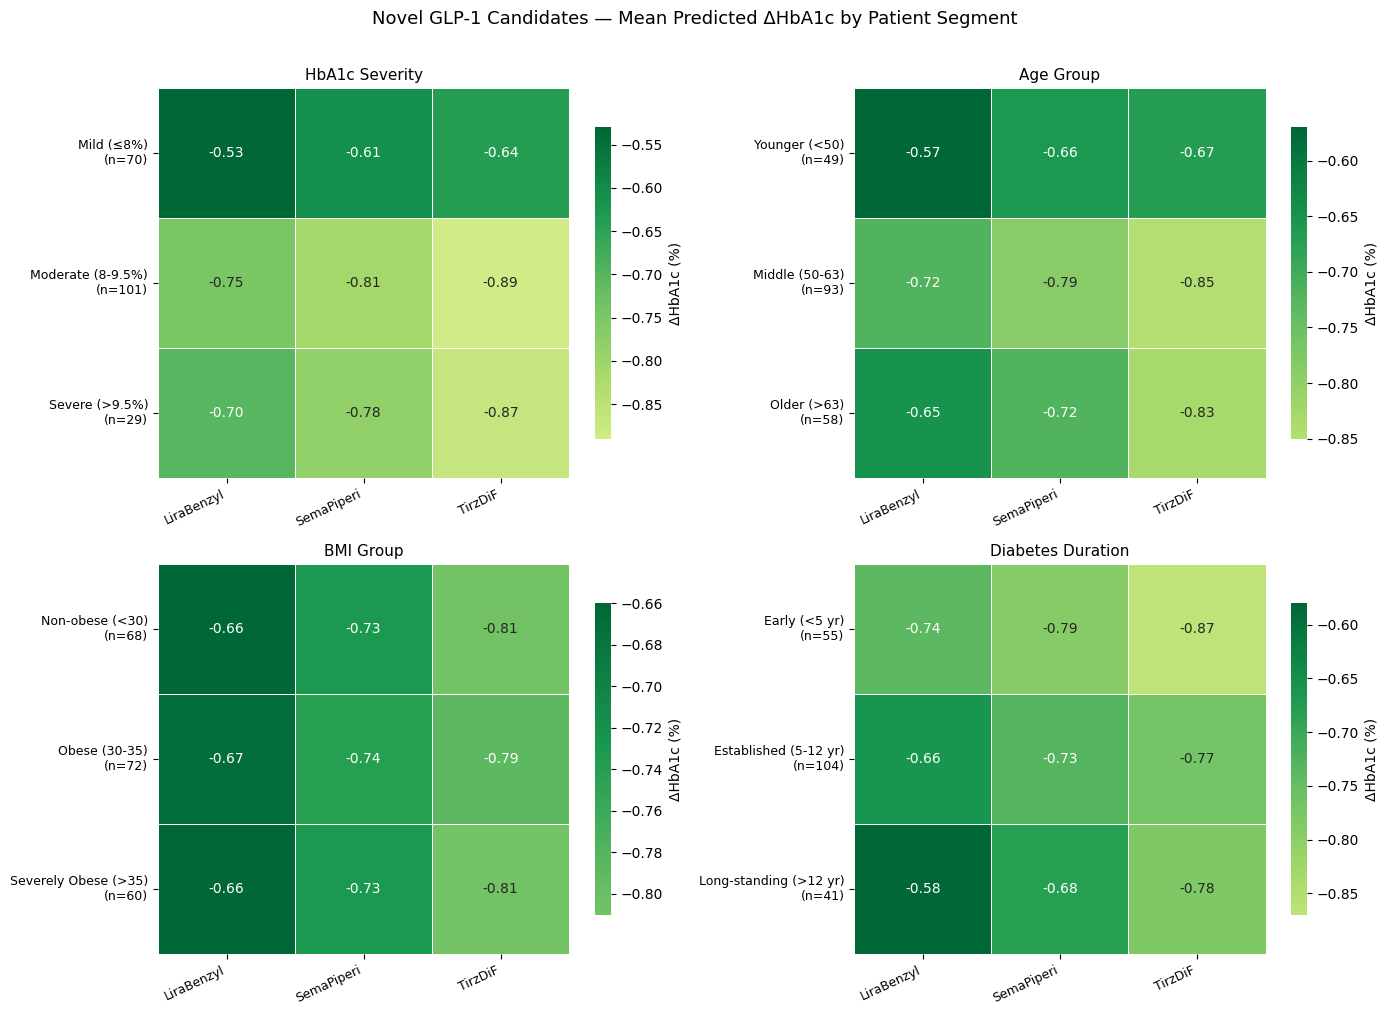


BEST RESPONDER PROFILE — Novel Candidates
(Top 25% responders vs Bottom 25% — sorted by largest difference)

LiraBenzyl  (C16 terminal CH₃ → benzyl (–CH₂Ph))
  Best responders n=50 | Poor responders n=50

          Feature  Best (mean)  Poor (mean)   Diff
        weight_kg        86.34       100.21 -13.87
              age        58.56        53.75   4.81
diabetes_duration         6.70         9.98  -3.28
   baseline_hba1c         8.96         7.83   1.13
              bmi        32.13        31.91   0.22
  fasting_glucose         9.11         9.25  -0.14
      has_obesity         0.52         0.66  -0.14
 has_hypertension         0.54         0.44   0.10
 has_dyslipidemia         0.52         0.46   0.06
   has_neuropathy         0.20         0.24  -0.04
        has_nafld         0.32         0.30   0.02
          has_ckd         0.14         0.16  -0.02
          has_cvd         0.16         0.16   0.00
  has_retinopathy         0.16         0.16   0.00

SemaPiperi  (C18 diacid COOH

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ── SMILES for the 3 novel candidates ─────────────────────────────────────────
print("=" * 70)
print("SMILES STRINGS — Novel GLP-1 Candidates (Step 13)")
print("=" * 70)
for drug in NOVEL_DRUGS:
    print(f"\n{drug['name']}  ({drug['modification']})")
    print(f"  Base drug : {drug['base']}")
    print(f"  SMILES    : {drug['smiles']}")
print("=" * 70)

# ── Build synthetic patient cohort ────────────────────────────────────────────
np.random.seed(42)
N = 200

cohort = pd.DataFrame({
    'patient_id':           range(N),
    'baseline_hba1c':       np.clip(np.random.normal(8.5, 1.2, N), 6.5, 13.0),
    'bmi':                  np.clip(np.random.normal(32,   5,   N), 22,  50),
    'age':                  np.clip(np.random.normal(58,   10,  N), 30,  80),
    'diabetes_duration':    np.clip(np.random.normal(8,    5,   N), 0.5, 30),
    'weight_kg':            np.clip(np.random.normal(90,   18,  N), 50,  160),
    'fasting_glucose':      np.clip(np.random.normal(9.0,  2.0, N), 4,   20),
    'trial_duration_weeks': np.full(N, 26.0),
    'has_obesity':          (np.random.rand(N) < 0.60).astype(int),
    'has_hypertension':     (np.random.rand(N) < 0.55).astype(int),
    'has_cvd':              (np.random.rand(N) < 0.20).astype(int),
    'has_ckd':              (np.random.rand(N) < 0.15).astype(int),
    'has_dyslipidemia':     (np.random.rand(N) < 0.50).astype(int),
    'has_nafld':            (np.random.rand(N) < 0.25).astype(int),
    'has_neuropathy':       (np.random.rand(N) < 0.20).astype(int),
    'has_retinopathy':      (np.random.rand(N) < 0.15).astype(int),
})
PATIENT_COLS = [c for c in cohort.columns if c != 'patient_id']

# ── Predictions across cohort ─────────────────────────────────────────────────
print("\nRunning predictions across 200-patient cohort...")
records = []
for drug in NOVEL_DRUGS:
    for _, row in cohort.iterrows():
        out = predict_from_smiles(drug['smiles'], row[PATIENT_COLS].to_dict())
        records.append({
            'patient_id':      row['patient_id'],
            'drug_name':       drug['name'],
            'predicted_delta': out['predicted_delta_hba1c'],
            'p_responder':     out['proba_meaningful_response'],
            **row[PATIENT_COLS].to_dict(),
        })
novel_pred_df = pd.DataFrame(records)
print(f"Done — {len(novel_pred_df)} predictions")

# ── Segment heatmaps only ─────────────────────────────────────────────────────
seg = novel_pred_df.copy()
seg['HbA1c Severity']   = pd.cut(seg['baseline_hba1c'],
    bins=[0, 8.0, 9.5, 15], labels=['Mild (≤8%)', 'Moderate (8-9.5%)', 'Severe (>9.5%)'])
seg['Age Group']         = pd.cut(seg['age'],
    bins=[0, 50, 63, 100],  labels=['Younger (<50)', 'Middle (50-63)', 'Older (>63)'])
seg['BMI Group']         = pd.cut(seg['bmi'],
    bins=[0, 30, 35, 100],  labels=['Non-obese (<30)', 'Obese (30-35)', 'Severely Obese (>35)'])
seg['Diabetes Duration'] = pd.cut(seg['diabetes_duration'],
    bins=[0, 5, 12, 30],    labels=['Early (<5 yr)', 'Established (5-12 yr)', 'Long-standing (>12 yr)'])

SEGMENTS   = ['HbA1c Severity', 'Age Group', 'BMI Group', 'Diabetes Duration']
drug_order = [d['name'] for d in NOVEL_DRUGS]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Novel GLP-1 Candidates — Mean Predicted ΔHbA1c by Patient Segment',
             fontsize=13, y=1.01)

for ax, seg_col in zip(axes.flat, SEGMENTS):
    grp    = (seg.groupby([seg_col, 'drug_name'])['predicted_delta']
                 .mean().unstack('drug_name').reindex(columns=drug_order))
    counts = seg.drop_duplicates('patient_id').groupby(seg_col).size()
    ylabels = [f'{s}\n(n={counts.get(s, 0)})' for s in grp.index]
    sns.heatmap(grp.round(2), ax=ax, cmap='RdYlGn', center=-1.0,
                annot=True, fmt='.2f', annot_kws={'size': 10},
                linewidths=0.5, cbar_kws={'label': 'ΔHbA1c (%)', 'shrink': 0.8})
    ax.set_yticklabels(ylabels, fontsize=9, rotation=0)
    ax.set_xticklabels(drug_order, rotation=25, ha='right', fontsize=9)
    ax.set_title(seg_col, fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# ── Best responder profile per novel drug ─────────────────────────────────────
print("\n" + "=" * 65)
print("BEST RESPONDER PROFILE — Novel Candidates")
print("(Top 25% responders vs Bottom 25% — sorted by largest difference)")
print("=" * 65)

numeric_feats = ['baseline_hba1c', 'bmi', 'age', 'diabetes_duration',
                 'weight_kg', 'fasting_glucose']
binary_feats  = ['has_obesity', 'has_hypertension', 'has_cvd', 'has_ckd',
                 'has_dyslipidemia', 'has_nafld', 'has_neuropathy', 'has_retinopathy']

for drug_name in drug_order:
    sub    = novel_pred_df[novel_pred_df['drug_name'] == drug_name]
    top    = sub[sub['predicted_delta'] <= sub['predicted_delta'].quantile(0.25)]
    bottom = sub[sub['predicted_delta'] >= sub['predicted_delta'].quantile(0.75)]
    mod    = next(d['modification'] for d in NOVEL_DRUGS if d['name'] == drug_name)

    print(f"\n{drug_name}  ({mod})")
    print(f"  Best responders n={len(top)} | Poor responders n={len(bottom)}\n")

    rows = [{'Feature': f,
             'Best (mean)': round(top[f].mean(), 2),
             'Poor (mean)': round(bottom[f].mean(), 2),
             'Diff':        round(top[f].mean() - bottom[f].mean(), 2)}
            for f in numeric_feats + binary_feats]

    print(pd.DataFrame(rows)
            .sort_values('Diff', key=abs, ascending=False)
            .to_string(index=False))


In [ ]:
# ── Classifier Evaluation — Confusion Matrix & Metrics ──────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

y_pred_clf = clf_model.predict(X_test)

# Text report
print(classification_report(y_clf_test, y_pred_clf, target_names=["Non-Responder", "Responder"]))

precision = precision_score(y_clf_test, y_pred_clf, zero_division=0)
recall    = recall_score(y_clf_test, y_pred_clf, zero_division=0)
f1        = f1_score(y_clf_test, y_pred_clf, zero_division=0)
accuracy  = accuracy_score(y_clf_test, y_pred_clf)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#09100f")
fig.suptitle("Classifier Performance — Held-Out Test Set", fontsize=13,
             color="#e8f0ee", y=1.02)

# Left: confusion matrix heatmap
cm = confusion_matrix(y_clf_test, y_pred_clf)
labels = ["Non-Responder", "Responder"]

ax_cm = axes[0]
ax_cm.set_facecolor("#0e1a18")
ax_cm.imshow(cm, cmap="YlGnBu", aspect="auto", vmin=0)

for i in range(2):
    for j in range(2):
        text_color = "#09100f" if cm[i, j] > cm.max() / 2 else "#e8f0ee"
        ax_cm.text(j, i, cm[i, j], ha="center", va="center",
                   fontsize=22, fontweight="bold", color=text_color)

ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(labels, color="#7fa89e", fontsize=10)
ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(labels, color="#7fa89e", fontsize=10,
                                                  rotation=90, va="center")
ax_cm.set_xlabel("Predicted", color="#7fa89e", fontsize=11, labelpad=8)
ax_cm.set_ylabel("Actual", color="#7fa89e", fontsize=11, labelpad=8)
ax_cm.set_title("Confusion Matrix", color="#4fd1b5", fontsize=11, pad=10)
ax_cm.tick_params(colors="#7fa89e")
for spine in ax_cm.spines.values():
    spine.set_edgecolor("#1a3a35")

# Right: metric bar chart
ax_bar = axes[1]
ax_bar.set_facecolor("#0e1a18")

metric_names  = ["AUC-ROC", "Precision", "Recall", "F1 Score", "Accuracy"]
metric_values = [auc, precision, recall, f1, accuracy]
bar_colors    = ["#4fd1b5", "#4fd1b5", "#4fd1b5", "#e8c97a", "#e8c97a"]

bars = ax_bar.barh(metric_names, metric_values, color=bar_colors, height=0.5)
ax_bar.set_xlim(0, 1.18)
ax_bar.set_xlabel("Score", color="#7fa89e", fontsize=10)
ax_bar.set_title("Classification Metrics", color="#4fd1b5", fontsize=11, pad=10)
ax_bar.tick_params(colors="#7fa89e")
ax_bar.set_yticklabels(metric_names, color="#e8f0ee", fontsize=10)
for spine in ax_bar.spines.values():
    spine.set_edgecolor("#1a3a35")

for bar, val in zip(bars, metric_values):
    ax_bar.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", color="#e8f0ee", fontsize=10)

plt.tight_layout()
plt.show()

# ── Website values ───────────────────────────────────────────────────────────
print("
── Values to copy into index.html ──────────────────────────────────────")
print(f"  AUC-ROC:   {auc:.3f}   (data-width="{round(auc*100)}")")
print(f"  Precision: {precision:.3f}   (data-width="{round(precision*100)}")")
print(f"  Recall:    {recall:.3f}   (data-width="{round(recall*100)}")")
print(f"  F1 Score:  {f1:.3f}   (data-width="{round(f1*100)}")")
print(f"  Accuracy:  {accuracy:.3f}   (data-width="{round(accuracy*100)}")")


## Step 14: Handoff Datasets for Demo Application

Exports everything needed for the web app:

| File | Contents |
|------|----------|
| `reg_model.pkl` | XGBoost regression — predicts ΔHbA1c (continuous) |
| `clf_model.pkl` | XGBoost classifier — predicts P(responder) |
| `feature_cols.pkl` | Ordered list of all 2,000+ feature names (required for inference) |
| `novel_drugs_catalog.pkl` | 3 novel candidate metadata + SMILES + precomputed drug vectors |
| `novel_drug_vectors.csv` | Same vectors as human-readable CSV |
| `patient_input_schema.json` | All patient fields with types, ranges, labels for the UI form |
| `example_patients.json` | 3 test patient profiles for smoke-testing the app |

**App flow:** user selects drug from dropdown → enters patient info → app calls `predict_from_smiles(smiles, patient)` → returns ΔHbA1c + P(responder).


In [181]:
import pickle, json, os
import pandas as pd
from rdkit.Chem import rdMolDescriptors

OUT = '../'   # c:/capstone_project/

# ── 1. Verify existing model files ────────────────────────────────────────────
print("Existing model files:")
for fname in ['reg_model.pkl', 'clf_model.pkl', 'feature_cols.pkl',
              'drug_features.pkl', 'demo_drugs.pkl']:
    path = OUT + fname
    status = f"{os.path.getsize(path)/1024:.1f} KB" if os.path.exists(path) else "MISSING"
    print(f"  {'OK' if os.path.exists(path) else '!!'} {fname:<25} {status}")

# ── 2. Pre-compute drug feature vectors for the 3 novel candidates ────────────
print("\nPre-computing drug vectors for novel candidates...")
from rdkit import Chem
from rdkit.Chem import AllChem

novel_drug_data = []
for drug in NOVEL_DRUGS:
    mol = Chem.MolFromSmiles(drug['smiles'])
    with _suppress_output():
        fp          = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        admet_preds = _admet_model.predict(smiles=[drug['smiles']])
    fp_dict    = {f'fp_{i}': int(fp[i]) for i in range(2048)}
    admet_dict = admet_preds.iloc[0].to_dict()
    novel_drug_data.append({
        'name':         drug['name'],
        'base_drug':    drug['base'],
        'modification': drug['modification'],
        'rationale':    drug.get('rationale', ''),
        'smiles':       drug['smiles'],
        'mol_weight_da': round(rdMolDescriptors.CalcExactMolWt(mol), 2),
        'fp_bits_set':  int(fp.GetNumOnBits()),
        'drug_vector':  {**fp_dict, **admet_dict},   # 2048 fp + ~104 ADMET features
    })
    print(f"  {drug['name']:<14} MW={novel_drug_data[-1]['mol_weight_da']:.1f} Da  "
          f"fp_bits={novel_drug_data[-1]['fp_bits_set']}  admet_cols={len(admet_dict)}")

with open(OUT + 'novel_drugs_catalog.pkl', 'wb') as f:
    pickle.dump(novel_drug_data, f)
print(f"\nSaved novel_drugs_catalog.pkl")

# Human-readable CSV of drug vectors
drug_vec_df = pd.DataFrame([
    {'drug_name': d['name'], 'base_drug': d['base_drug'],
     'modification': d['modification'], 'smiles': d['smiles'], **d['drug_vector']}
    for d in novel_drug_data
])
drug_vec_df.to_csv(OUT + 'novel_drug_vectors.csv', index=False)
print(f"Saved novel_drug_vectors.csv  shape: {drug_vec_df.shape}")

# ── 3. Patient input schema (drives the web app form) ─────────────────────────
patient_schema = {
    "continuous_inputs": [
        {"field": "baseline_hba1c",       "label": "Baseline HbA1c (%)",          "type": "number",
         "min": 6.5,  "max": 14.0, "step": 0.1, "example": 8.5,  "required": True,
         "description": "HbA1c % at start of treatment"},
        {"field": "bmi",                   "label": "BMI (kg/m²)",                 "type": "number",
         "min": 18.0, "max": 55.0, "step": 0.1, "example": 32.0, "required": True,
         "description": "Body mass index"},
        {"field": "age",                   "label": "Age (years)",                 "type": "number",
         "min": 18,   "max": 90,   "step": 1,   "example": 58,   "required": True,
         "description": "Patient age"},
        {"field": "diabetes_duration",     "label": "Diabetes Duration (years)",   "type": "number",
         "min": 0,    "max": 40,   "step": 0.5, "example": 8.0,  "required": False,
         "description": "Years since T2D diagnosis — leave blank if unknown"},
        {"field": "weight_kg",             "label": "Weight (kg)",                 "type": "number",
         "min": 40,   "max": 200,  "step": 0.5, "example": 90.0, "required": False,
         "description": "Body weight — leave blank if unknown"},
        {"field": "fasting_glucose",       "label": "Fasting Glucose (mmol/L)",    "type": "number",
         "min": 3.0,  "max": 25.0, "step": 0.1, "example": 9.2,  "required": False,
         "description": "Fasting blood glucose — leave blank if unknown"},
        {"field": "trial_duration_weeks",  "label": "Treatment Duration (weeks)",  "type": "number",
         "min": 12,   "max": 104,  "step": 4,   "example": 26,   "required": False,
         "default": 26, "description": "Planned treatment length — defaults to 26 weeks"},
    ],
    "binary_inputs": [
        {"field": "has_obesity",      "label": "Obesity (BMI ≥ 30)",           "type": "checkbox"},
        {"field": "has_hypertension", "label": "Hypertension",                  "type": "checkbox"},
        {"field": "has_cvd",          "label": "Cardiovascular Disease",        "type": "checkbox"},
        {"field": "has_ckd",          "label": "Chronic Kidney Disease",        "type": "checkbox"},
        {"field": "has_dyslipidemia", "label": "Dyslipidemia",                  "type": "checkbox"},
        {"field": "has_nafld",        "label": "Non-Alcoholic Fatty Liver (NAFLD)", "type": "checkbox"},
        {"field": "has_neuropathy",   "label": "Diabetic Neuropathy",           "type": "checkbox"},
        {"field": "has_retinopathy",  "label": "Diabetic Retinopathy",          "type": "checkbox"},
    ],
    "drug_dropdown": [
        {"value": d['name'],
         "label": f"{d['name']} — {d['modification']}",
         "base_drug": d['base_drug'],
         "smiles": d['smiles'],
         "rationale": d.get('rationale', '')}
        for d in novel_drug_data
    ],
    "model_outputs": [
        {"field": "predicted_delta_hba1c",     "label": "Predicted ΔHbA1c (%)",
         "description": "Negative = HbA1c reduction. Values ≤ −1% considered clinically meaningful."},
        {"field": "proba_meaningful_response",  "label": "P(Responder)",
         "description": "Probability of achieving > 1% HbA1c reduction. ≥ 0.5 = Likely Responder."},
        {"field": "responder_label",            "label": "Outcome",
         "description": "'Likely Responder' or 'Unlikely Responder'"},
    ]
}

with open(OUT + 'patient_input_schema.json', 'w') as f:
    json.dump(patient_schema, f, indent=2)
print("Saved patient_input_schema.json")

# ── 4. Example patients for smoke-testing the app ─────────────────────────────
example_patients = [
    {"label": "Typical T2D patient",
     "baseline_hba1c": 8.5, "bmi": 32.0, "age": 58.0, "diabetes_duration": 8.0,
     "weight_kg": 90.0, "fasting_glucose": 9.2, "trial_duration_weeks": 26.0,
     "has_obesity": 1, "has_hypertension": 1, "has_cvd": 0, "has_ckd": 0,
     "has_dyslipidemia": 1, "has_nafld": 0, "has_neuropathy": 0, "has_retinopathy": 0},
    {"label": "Young, severe HbA1c, high BMI",
     "baseline_hba1c": 11.0, "bmi": 42.0, "age": 38.0, "diabetes_duration": 3.0,
     "weight_kg": 120.0, "fasting_glucose": 13.5, "trial_duration_weeks": 26.0,
     "has_obesity": 1, "has_hypertension": 0, "has_cvd": 0, "has_ckd": 0,
     "has_dyslipidemia": 1, "has_nafld": 1, "has_neuropathy": 0, "has_retinopathy": 0},
    {"label": "Older patient, long-standing T2D with complications",
     "baseline_hba1c": 7.8, "bmi": 28.0, "age": 72.0, "diabetes_duration": 18.0,
     "weight_kg": 78.0, "fasting_glucose": 8.1, "trial_duration_weeks": 26.0,
     "has_obesity": 0, "has_hypertension": 1, "has_cvd": 1, "has_ckd": 1,
     "has_dyslipidemia": 1, "has_nafld": 0, "has_neuropathy": 1, "has_retinopathy": 1},
]

with open(OUT + 'example_patients.json', 'w') as f:
    json.dump(example_patients, f, indent=2)
print(f"Saved example_patients.json  ({len(example_patients)} patients)")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("Step 14 exports complete — files in c:/capstone_project/")
print("=" * 55)
exports = [
    ('reg_model.pkl',             'XGBoost regression (predicts ΔHbA1c)'),
    ('clf_model.pkl',             'XGBoost classifier (predicts P(responder))'),
    ('feature_cols.pkl',          'Ordered feature list for inference'),
    ('novel_drugs_catalog.pkl',   '3 novel candidates + vectors'),
    ('novel_drug_vectors.csv',    'Drug vectors as CSV'),
    ('patient_input_schema.json', 'UI form field definitions'),
    ('example_patients.json',     '3 test patients'),
]
for fname, desc in exports:
    path = OUT + fname
    size = f"{os.path.getsize(path)/1024:.1f} KB" if os.path.exists(path) else "MISSING"
    print(f"  {fname:<30} {size:<10} {desc}")


Existing model files:
  OK reg_model.pkl             258.5 KB
  OK clf_model.pkl             241.2 KB
  OK feature_cols.pkl          22.2 KB
  OK drug_features.pkl         106.8 KB
  OK demo_drugs.pkl            4.5 KB

Pre-computing drug vectors for novel candidates...
  LiraBenzyl     MW=3825.0 Da  fp_bits=140  admet_cols=104
  SemaPiperi     MW=4178.2 Da  fp_bits=172  admet_cols=104
  TirzDiF        MW=4846.5 Da  fp_bits=183  admet_cols=104

Saved novel_drugs_catalog.pkl
Saved novel_drug_vectors.csv  shape: (3, 2156)
Saved patient_input_schema.json
Saved example_patients.json  (3 patients)

Step 14 exports complete — files in c:/capstone_project/
  reg_model.pkl                  258.5 KB   XGBoost regression (predicts ΔHbA1c)
  clf_model.pkl                  241.2 KB   XGBoost classifier (predicts P(responder))
  feature_cols.pkl               22.2 KB    Ordered feature list for inference
  novel_drugs_catalog.pkl        82.0 KB    3 novel candidates + vectors
  novel_drug_vectors.c